In [ ]:
# Paths - edit for your environment
SUPREMO_DIR = "/pollard/home/szhang20/akita_variant_scoring"
AKITA_DIR = "/pollard/home/szhang20/akita"
PROJECT_DIR = "/pollard/home/szhang20/alu"


In [1]:
%load_ext autoreload


In [2]:
%cd ~/akita_variant_scoring/

/pollard/home/szhang20/akita_variant_scoring


In [3]:
import numpy as np
import pandas as pd
import sys, os, psutil, time, io
import math, re, random
import matplotlib.pyplot as plt
import pysam 


In [4]:
#temporary fix
sys.path.insert(0, '../scripts')
os.chdir(f'{SUPREMO_DIR}/scripts/')

import plotting_utils
import get_Akita_scores_utils
import get_seq_utils


I0000 00:00:1784690004.156682 1020505 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784690006.084977 1020505 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784690013.404935 1020505 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


RUNNIGN SEQNN GPU 
memory limit per process is 6.5gb!
repo path /pollard/home/szhang20/akita_variant_scoring/scripts/..


E0000 00:00:1784690016.148622 1020505 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


dynamic shape Tensor("Shape:0", shape=(4,), dtype=int32)
seq_len Tensor("strided_slice:0", shape=(), dtype=int32)
diag offset 2


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 1048576,   │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_reverse… │ [(None, 1048576,  │          0 │ sequence[0][0]    │
│ (StochasticReverse… │ 4), ()]           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_shift    │ (None, 1048576,   │          0 │ stochastic_rever… │
│ (StochasticShift)   │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 1048576,   │          0 │ stochastic_shift… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1048576,   │      4,224 │ re_lu[0][0]       │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1048576,   │        384 │ conv1d[0][0]      │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 524288,    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 524288,    │          0 │ max_pooling1d[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 524288,    │     46,080 │ re_lu_1[0][0]     │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 524288,    │        384 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 262144,    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 262144,    │          0 │ max_pooling1d_1[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 262144,    │     46,080 │ re_lu_2[0][0]     │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 262144,    │        384 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 131072,    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 131072,    │          0 │ max_pooling1d_2[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 131072,    │     46,080 │ re_lu_3[0][0]   

 Total params: 751,653 (2.87 MB)

 Trainable params: 746,149 (2.85 MB)

 Non-trainable params: 5,504 (21.50 KB)

None
model_strides [2048]
target_lengths [99681]
target_crops [-49585]
Akita successfully loaded


In [5]:
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.backends.backend_pdf as pdf_backend
import matplotlib.font_manager as fm
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.colors as mcolors

PLOT_RC = {
    'font.family'        : 'sans-serif',
    'font.sans-serif'    : ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size'          : 7,
    'axes.titlesize'     : 8,
    'axes.labelsize'     : 7,
    'xtick.labelsize'    : 6,
    'ytick.labelsize'    : 6,
    'legend.fontsize'    : 6,
    'axes.linewidth'     : 0.6,
    'axes.edgecolor'     : 'black',
    'axes.facecolor'     : 'white',
    'figure.facecolor'   : 'white',
    'axes.grid'          : False,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.spines.left'   : True,
    'axes.spines.bottom' : True,
    'xtick.direction'    : 'out',
    'ytick.direction'    : 'out',
    'xtick.major.size'   : 2.5,
    'ytick.major.size'   : 2.5,
    'xtick.major.width'  : 0.5,
    'ytick.major.width'  : 0.5,
    'lines.linewidth'    : 0.9,
    'figure.dpi'         : 150,
    'savefig.dpi'        : 600,
    'savefig.bbox'       : 'tight',
    'pdf.fonttype'       : 42,
    'ps.fonttype'        : 42,
    'svg.fonttype'       : 'none',
    'figure.titlesize'   : 8,
}



In [6]:
from matplotlib.backends.backend_pdf import PdfPages
def save_figures_to_pdf(output_pdf_path, figures):
    with PdfPages(output_pdf_path) as pdf:
        for fig in figures:
            pdf.savefig(fig)


# define the boundary values where color changes
bounds = [-2, 0, 2]   # N+1 edges → N bands
colors = ['#393B79', '#5254A3', '#6B6ECF', '#9C9EDE', '#ffffff', '#E6B8BF', '#CC7A88', '#B33E52', '#990F26']

rdbu_modified = [
    '#1a1f6b',  # deep indigo
    '#3a62b0',
    '#7a9fd4',
    '#c4cfe8',
    '#f7f7f7',  # center
    '#f2b49a',  # was #f4a582 — muted
    '#d4765f',  # was #d6604d — muted
    '#a8303f',  # was #b2182b — muted
    '#5c1020',  # was #67001f — muted deep red
]
cmap_pred = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", rdbu_modified, N=256)

prgn_modified = [
    '#3b2255',
    '#6b3d7a',
    '#9b6aaa',
    '#c4a3c8',
    '#e8dff0',
    '#f7f7f7',  # center
    '#ccddb8',  # more gray-green
    '#8aaf72',  # earthier sage
    '#4e8a4e',  # proper sage
    '#2a5c35',  # dark muted sage
    '#0f3320',  # deep sage, almost olive
]

cmap_diff = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", prgn_modified, N=256)


In [7]:
# Data path
repo_path=f'{SUPREMO_DIR}/'
genome='hg38'

chrom_lengths_path = f'{repo_path}/data/chrom_lengths_{genome}'
centromere_coords_path = f'{repo_path}/data/centromere_coords_{genome}'

chrom_lengths = pd.read_table(chrom_lengths_path, header = None, names = ['CHROM', 'chrom_max'])
centromere_coords = pd.read_table(centromere_coords_path, sep = '\t')
fasta_open=pysam.FastaFile(f'{repo_path}/data/{genome}.fa')

svlen_limit=1_000_000
seq_len=1048576
bin_size=2048
###
get_seq_utils.fasta_open = fasta_open
get_seq_utils.chrom_lengths = chrom_lengths
get_seq_utils.centromere_coords = centromere_coords

get_seq_utils.svlen_limit = svlen_limit
get_seq_utils.seq_length = seq_len
get_seq_utils.half_patch_size = round(seq_len/2)

get_Akita_scores_utils.chrom_lengths = chrom_lengths
get_Akita_scores_utils.centromere_coords = centromere_coords




In [8]:
def mse_track(map_a, map_b):

    # Get vector with mean of squared differences for each row 

    sub_map = map_a - map_b

    mse_track = []
    for i in range(0,len(sub_map)):

        # Get non-nan values in ith row
        non_nan_values = np.count_nonzero(~np.isnan(sub_map[i]))

        # if there are values in ith row, get mean of squared differences
        if non_nan_values > 0:
            row_sum = np.nansum([x**2 for x in sub_map[i]])
            row_avg = row_sum/non_nan_values

        # if the whole ith row is nan, MSE is nan for ith row
        else:
            row_avg = np.nan

        # save mean of squared differences for ith row
        mse_track.append(row_avg)

    mse_track = np.array(mse_track) 



In [9]:
res_dir=f'{PROJECT_DIR}/results/paper_results/'

In [10]:
alu=pd.read_csv(f'{res_dir}20260316_merged_aluhg38_all_featureannot_NA_blacklist_filter_region_alu.txt', sep='\t', index_col=0)

In [11]:
q99_mse=np.quantile(alu['mse_mean'], 0.99)
q10_mse=np.quantile(alu['mse_mean'], 0.10)

alu_low=alu[alu['mse_mean']<q10_mse].sort_values('mse_mean', ascending=True)
alu_high=alu[alu['mse_mean']>q99_mse].sort_values('mse_mean', ascending=False)


In [12]:
alu_high[0:20]

,CHROM,POS,END,repName,strand,orig_idx,mse_mean,corr_mean,single_gene_name,single_gene_type,single_gene_overlap_bp,swScore,milliDel,id,#bin,milliIns,milliDiv,SVLEN,REF_start,REF_stop,GC_alu,GC_1kb,GC_10kb,GC_100kb,GC_1Mb,mapp36_alu,mapp36_1kb,mapp36_10kb,mapp36_100kb,mapp36_1Mb,mapp100_alu,mapp100_1kb,mapp100_10kb,mapp100_100kb,mapp100_1Mb,phyloP30_alu,phyloP30_1kb,phyloP30_10kb,phyloP30_100kb,phyloP30_1Mb,phyloP100_alu,phyloP100_1kb,phyloP100_10kb,phyloP100_100kb,phyloP100_1Mb,phastCon30_alu,phastCon30_1kb,phastCon30_10kb,phastCon30_100kb,phastCon30_1Mb,phastCon100_alu,phastCon100_1kb,phastCon100_10kb,phastCon100_100kb,phastCon100_1Mb,alu_count_alu,alu_count_1kb,alu_count_10kb,alu_count_100kb,alu_count_1Mb,promoter_count_alu,promoter_count_1kb,promoter_count_10kb,promoter_count_100kb,promoter_count_1Mb,HFF_CTCF_count_alu,HFF_CTCF_count_1kb,HFF_CTCF_count_10kb,HFF_CTCF_count_100kb,HFF_CTCF_count_1Mb,H1ESC_WGBS_count_alu,H1ESC_WGBS_count_1kb,H1ESC_WGBS_count_10kb,H1ESC_WGBS_count_100kb,H1ESC_WGBS_count_1Mb,gene_PC_overlap_alu,gene_PC_overlap_1kb,gene_PC_overlap_10kb,gene_PC_overlap_100kb,gene_PC_overlap_1Mb,pseudogene_overlap_alu,pseudogene_overlap_1kb,pseudogene_overlap_10kb,pseudogene_overlap_100kb,pseudogene_overlap_1Mb,lincRNA_overlap_alu,lincRNA_overlap_1kb,lincRNA_overlap_10kb,lincRNA_overlap_100kb,lincRNA_overlap_1Mb,ZNF_overlap_alu,ZNF_overlap_1kb,ZNF_overlap_10kb,ZNF_overlap_100kb,ZNF_overlap_1Mb,HFF_H3K9me3_overlap_alu,HFF_H3K9me3_overlap_1kb,HFF_H3K9me3_overlap_10kb,HFF_H3K9me3_overlap_100kb,HFF_H3K9me3_overlap_1Mb,HFF_H3K27me3_overlap_alu,HFF_H3K27me3_overlap_1kb,HFF_H3K27me3_overlap_10kb,HFF_H3K27me3_overlap_100kb,HFF_H3K27me3_overlap_1Mb,repeats_overlap_alu,repeats_overlap_1kb,repeats_overlap_10kb,repeats_overlap_100kb,repeats_overlap_1Mb,phyloP100_highfrac_alu,phyloP100_lowfrac_alu,phyloP100_highfrac_1kb,phyloP100_lowfrac_1kb,phyloP100_highfrac_10kb,phyloP100_lowfrac_10kb,phyloP100_highfrac_100kb,phyloP100_lowfrac_100kb,phyloP100_highfrac_1Mb,phyloP100_lowfrac_1Mb,seg_dup_overlap_alu,seg_dup_overlap_1kb,seg_dup_overlap_10kb,seg_dup_overlap_100kb,seg_dup_overlap_1Mb,self_chain_overlap_alu,self_chain_overlap_1kb,self_chain_overlap_10kb,self_chain_overlap_100kb,self_chain_overlap_1Mb
873494,chr5,141090261,141090567,AluSz6,-,351424,0.149897,0.863097,AC244517.5,antisense,306,1646,7,3,1661,23,189,306,140566126.0,141614702.0,0.516340,0.404,0.3684,0.38478,0.417373,0.816930,0.938792,0.971273,0.936453,0.928936,1.000000,0.999811,0.996557,0.982668,0.990089,0.108540,0.124864,0.181680,0.190509,0.210879,0.071717,0.103644,0.039904,0.152193,0.290290,0.210321,0.175858,0.171225,0.209686,0.241606,0.201624,0.108557,0.125242,0.120172,0.156971,1,1,3,50,595,0,0,1,5,64,0,0,2,9,110,5,7,73,845,10756,0.0,0.000,0.0836,0.22919,0.690981,0.0,0.0,0.0,0.00000,0.043564,0.000000,0.000,0.0000,0.08490,0.011729,0.0,0.0,0.0,0.0,0.0,0.000000,0.000,0.0138,0.12359,0.261202,0.000000,0.000,0.0360,0.01486,0.024795,1.0,0.702,0.2731,0.47236,0.469223,0.000000,0.009804,0.003,0.009,0.0572,0.0600,0.04800,0.03552,0.066889,0.034874,0.0,0.0,0.0000,0.05043,0.057915,1.0,1.0,1.0,1.0,0.784928
873451,chr5,141020617,141020922,AluSq2,+,351381,0.142258,0.878932,NaN,NaN,0,2121,23,3,1660,3,128,305,140496482.0,141545058.0,0.495082,0.360,0.3612,0.38622,0.419168,0.689255,0.900570,0.935961,0.954105,0.927030,1.000000,1.000000,0.992877,0.997836,0.989193,0.067919,0.166041,0.201274,0.245099,0.208689,-0.036241,0.074778,0.147250,0.311869,0.292223,0.051186,0.098401,0.171283,0.239466,0.243138,0.014459,0.043686,0.081271,0.145752,0.159014,1,1,6,50,603,0,0,0,1,69,0,0,0,3,103,1,2,49,751,10821,0.0,0.000,0.0000,0.49787,0.690966,0.0,0.0,0.0,0.00000,0.043366,0.000000,0.000,0.0000,0.00000,0.011729,0.0,0.0,0.0,0.0,0.0,0.000000,0.000,0.3341,0.15771,0.258430,0.000000,0.000,0.0000,0.00846,0.026131,1.0,0.305,0.5165,0.47842,0.467982,0.000000,0.022951,0.017,0.012,0.0315,0.0111,0.05368,0.01238,0.070883,0.034660,0.0,0.0,0.0000,0.00000,0.057915,1.0,1.0,1.0,1.0,0.825719
873508,chr5,141130149,141130427,AluSq4

In [14]:
alu_query=alu

#BDP1
#alu_bdp1=alu_query[(alu_query['CHROM']=='chr5') & (alu_query['POS']>71000000) & (alu_query['POS']<72000000)] 
#PDCH
#alu_bdp1=alu_query[(alu_query['CHROM']=='chr5') & (alu_query['POS']>140000001) & (alu_query['POS']<143000000)]
#ANKRD11
#alu_bdp1=alu_query[(alu_query['CHROM']=='chr16') & (alu_query['POS']>88000001) & (alu_query['POS']<91000001)]
#HIST and BTN genes 
#alu_bdp1=alu_query[(alu_query['CHROM']=='chr6') & (alu_query['POS']>26000001) & (alu_query['POS']<27000001)]
#chr9
#alu_bdp1=alu_query[(alu_query['CHROM']=='chr9') & (alu_query['POS']>136000001) & (alu_query['POS']<137000001)]

#alu_bdp1=alu_query[(alu_query['CHROM']=='chr16') & (alu_query['POS']>30000001) & (alu_query['POS']<31000001)]

#T cell receptor
alu_bdp1=alu_query[(alu_query['CHROM']=='chr14') & (alu_query['POS']>21000001) & (alu_query['POS']<22000001)]


alu_bdp1=alu_bdp1.sort_values(by='mse_mean', ascending=False)


,CHROM,POS,END,repName,strand,orig_idx,mse_mean,corr_mean,single_gene_name,single_gene_type,single_gene_overlap_bp,swScore,milliDel,id,#bin,milliIns,milliDiv,SVLEN,REF_start,REF_stop,GC_alu,GC_1kb,GC_10kb,GC_100kb,GC_1Mb,mapp36_alu,mapp36_1kb,mapp36_10kb,mapp36_100kb,mapp36_1Mb,mapp100_alu,mapp100_1kb,mapp100_10kb,mapp100_100kb,mapp100_1Mb,phyloP30_alu,phyloP30_1kb,phyloP30_10kb,phyloP30_100kb,phyloP30_1Mb,phyloP100_alu,phyloP100_1kb,phyloP100_10kb,phyloP100_100kb,phyloP100_1Mb,phastCon30_alu,phastCon30_1kb,phastCon30_10kb,phastCon30_100kb,phastCon30_1Mb,phastCon100_alu,phastCon100_1kb,phastCon100_10kb,phastCon100_100kb,phastCon100_1Mb,alu_count_alu,alu_count_1kb,alu_count_10kb,alu_count_100kb,alu_count_1Mb,promoter_count_alu,promoter_count_1kb,promoter_count_10kb,promoter_count_100kb,promoter_count_1Mb,HFF_CTCF_count_alu,HFF_CTCF_count_1kb,HFF_CTCF_count_10kb,HFF_CTCF_count_100kb,HFF_CTCF_count_1Mb,H1ESC_WGBS_count_alu,H1ESC_WGBS_count_1kb,H1ESC_WGBS_count_10kb,H1ESC_WGBS_count_100kb,H1ESC_WGBS_count_1Mb,gene_PC_overlap_alu,gene_PC_overlap_1kb,gene_PC_overlap_10kb,gene_PC_overlap_100kb,gene_PC_overlap_1Mb,pseudogene_overlap_alu,pseudogene_overlap_1kb,pseudogene_overlap_10kb,pseudogene_overlap_100kb,pseudogene_overlap_1Mb,lincRNA_overlap_alu,lincRNA_overlap_1kb,lincRNA_overlap_10kb,lincRNA_overlap_100kb,lincRNA_overlap_1Mb,ZNF_overlap_alu,ZNF_overlap_1kb,ZNF_overlap_10kb,ZNF_overlap_100kb,ZNF_overlap_1Mb,HFF_H3K9me3_overlap_alu,HFF_H3K9me3_overlap_1kb,HFF_H3K9me3_overlap_10kb,HFF_H3K9me3_overlap_100kb,HFF_H3K9me3_overlap_1Mb,HFF_H3K27me3_overlap_alu,HFF_H3K27me3_overlap_1kb,HFF_H3K27me3_overlap_10kb,HFF_H3K27me3_overlap_100kb,HFF_H3K27me3_overlap_1Mb,repeats_overlap_alu,repeats_overlap_1kb,repeats_overlap_10kb,repeats_overlap_100kb,repeats_overlap_1Mb,phyloP100_highfrac_alu,phyloP100_lowfrac_alu,phyloP100_highfrac_1kb,phyloP100_lowfrac_1kb,phyloP100_highfrac_10kb,phyloP100_lowfrac_10kb,phyloP100_highfrac_100kb,phyloP100_lowfrac_100kb,phyloP100_highfrac_1Mb,phyloP100_lowfrac_1Mb,seg_dup_overlap_alu,seg_dup_overlap_1kb,seg_dup_overlap_10kb,seg_dup_overlap_100kb,seg_dup_overlap_1Mb,self_chain_overlap_alu,self_chain_overlap_1kb,self_chain_overlap_10kb,self_chain_overlap_100kb,self_chain_overlap_1Mb
296401,chr14,21121542,21121848,AluSz6,-,846867,0.049343,0.894215,NaN,NaN,0,2171,7,1,746,7,131,306,20597407.0,21645983.0,0.506536,0.398,0.4033,0.45416,0.435807,0.778242,0.915994,0.911695,0.926681,0.901719,1.000000,1.000000,1.000216,0.993918,0.990667,0.008904,0.120127,0.100250,0.185454,0.093469,-0.080554,0.067561,0.066087,0.276938,0.165403,0.054853,0.104129,0.133767,0.253265,0.152345,0.031155,0.060313,0.093214,0.192892,0.124095,1,1,11,55,869,0,0,0,3,30,0,0,0,14,75,6,10,77,893,11379,0.0,0.0,0.0000,0.43717,0.436898,0.0,0.0,0.0000,0.04407,0.013783,0.0,0.0,0.0008,0.08660,0.052779,0.0,0.0,0.000,0.14676,0.013996,0.000000,0.000,0.0545,0.01642,0.013953,0.000000,0.000,0.0173,0.11721,0.099283,1.0,0.838,0.7899,0.53206,0.516863,0.000000,0.009804,0.007,0.011,0.0017,0.0110,0.06104,0.01360,0.041440,0.020444,0.0,0.0,0.0,0.04694,0.095371,1.0,1.0,1.0,1.0,1.0
296764,chr14,21451287,21451601,AluSx3,+,847230,0.048934,0.919095,CHD8,protein_coding,314,2335,0,1,748,10,99,314,20927156.0,21975732.0,0.519108,0.371,0.4340,0.42470,0.418435,0.517397,0.844797,0.866905,0.901222,0.913993,1.000000,1.000000,0.994723,0.999562,0.991592,-0.033338,0.213357,0.168550,0.220804,0.105878,-0.033394,0.184133,0.193982,0.452953,0.170116,0.084656,0.302272,0.176536,0.230783,0.149344,0.020564,0.097307,0.117521,0.169390,0.121827,1,1,13,112,769,0,0,0,3,24,0,0,0,7,61,5,11,138,1282,10750,1.0,1.0,0.9682,0.97106,0.417514,0.0,0.0,0.0000,0.00340,0.015158,0.0,0.0,0.0000,0.00000,0.023198,0.0,0.0,0.000,0.00000,0.013996,0.000000,0.000,0.0000,0.00000,0.124848,0.000000,0.000,0.0001,0.00488,0.065373,1.0,0.314,0.3831,0.42510,0.507401,0.000000,0.015924,0.034,0.016,0.0448,0.0133,0.08210,0.01564,0.041967,0.020074,0.0,0.0,0.0,0.04663,0.046319,1.0,1.0,1.0,1.0,1.0
296476,chr14,21226035,21226349,AluSx3,+,846942,

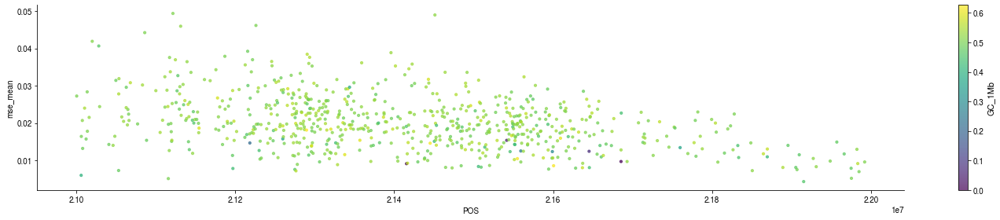

In [106]:
fig, ax = plt.subplots(figsize=(20,4))
color_col='GC_alu'
single_color='blue'



df = alu_bdp1.sort_values('POS')
sc=ax.scatter(x = df['POS'],y = df['mse_mean'],c = df['GC_alu'], alpha = 0.7,s = 10)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('GC_1Mb', fontsize=11)

ax.set_xlabel('POS')
ax.set_ylabel('mse_mean')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()




In [30]:
alu

,CHROM,POS,END,repName,strand,orig_idx,mse_mean,corr_mean,single_gene_name,single_gene_type,single_gene_overlap_bp,swScore,milliDel,id,#bin,milliIns,milliDiv,SVLEN,REF_start,REF_stop,GC_alu,GC_1kb,GC_10kb,GC_100kb,GC_1Mb,mapp36_alu,mapp36_1kb,mapp36_10kb,mapp36_100kb,mapp36_1Mb,mapp100_alu,mapp100_1kb,mapp100_10kb,mapp100_100kb,mapp100_1Mb,phyloP30_alu,phyloP30_1kb,phyloP30_10kb,phyloP30_100kb,phyloP30_1Mb,phyloP100_alu,phyloP100_1kb,phyloP100_10kb,phyloP100_100kb,phyloP100_1Mb,phastCon30_alu,phastCon30_1kb,phastCon30_10kb,phastCon30_100kb,phastCon30_1Mb,phastCon100_alu,phastCon100_1kb,phastCon100_10kb,phastCon100_100kb,phastCon100_1Mb,alu_count_alu,alu_count_1kb,alu_count_10kb,alu_count_100kb,alu_count_1Mb,promoter_count_alu,promoter_count_1kb,promoter_count_10kb,promoter_count_100kb,promoter_count_1Mb,HFF_CTCF_count_alu,HFF_CTCF_count_1kb,HFF_CTCF_count_10kb,HFF_CTCF_count_100kb,HFF_CTCF_count_1Mb,H1ESC_WGBS_count_alu,H1ESC_WGBS_count_1kb,H1ESC_WGBS_count_10kb,H1ESC_WGBS_count_100kb,H1ESC_WGBS_count_1Mb,gene_PC_overlap_alu,gene_PC_overlap_1kb,gene_PC_overlap_10kb,gene_PC_overlap_100kb,gene_PC_overlap_1Mb,pseudogene_overlap_alu,pseudogene_overlap_1kb,pseudogene_overlap_10kb,pseudogene_overlap_100kb,pseudogene_overlap_1Mb,lincRNA_overlap_alu,lincRNA_overlap_1kb,lincRNA_overlap_10kb,lincRNA_overlap_100kb,lincRNA_overlap_1Mb,ZNF_overlap_alu,ZNF_overlap_1kb,ZNF_overlap_10kb,ZNF_overlap_100kb,ZNF_overlap_1Mb,HFF_H3K9me3_overlap_alu,HFF_H3K9me3_overlap_1kb,HFF_H3K9me3_overlap_10kb,HFF_H3K9me3_overlap_100kb,HFF_H3K9me3_overlap_1Mb,HFF_H3K27me3_overlap_alu,HFF_H3K27me3_overlap_1kb,HFF_H3K27me3_overlap_10kb,HFF_H3K27me3_overlap_100kb,HFF_H3K27me3_overlap_1Mb,repeats_overlap_alu,repeats_overlap_1kb,repeats_overlap_10kb,repeats_overlap_100kb,repeats_overlap_1Mb,phyloP100_highfrac_alu,phyloP100_lowfrac_alu,phyloP100_highfrac_1kb,phyloP100_lowfrac_1kb,phyloP100_highfrac_10kb,phyloP100_lowfrac_10kb,phyloP100_highfrac_100kb,phyloP100_lowfrac_100kb,phyloP100_highfrac_1Mb,phyloP100_lowfrac_1Mb,seg_dup_overlap_alu,seg_dup_overlap_1kb,seg_dup_overlap_10kb,seg_dup_overlap_100kb,seg_dup_overlap_1Mb,self_chain_overlap_alu,self_chain_overlap_1kb,self_chain_overlap_10kb,self_chain_overlap_100kb,self_chain_overlap_1Mb
506,chr1,1264489,1264625,AluSx,+,741,0.021140,0.960404,UBE2J2,protein_coding,136,1063,0,1,594,0,110,136,740269.0,1788845.0,0.529412,0.510,0.5424,0.62453,0.568478,0.534221,0.780255,0.871165,0.942863,0.872339,1.0,1.0,0.998089,0.989701,0.951757,-0.028304,-0.075822,-0.106328,-0.123328,-0.102632,-0.084942,-0.161515,-0.156320,-0.222589,-0.114942,0.014371,0.019621,0.032537,0.071177,0.076884,0.019615,0.045403,0.034736,0.082544,0.089627,1,2,10,43,798,0,0,0,8,43,0,0,2,20,102,1,21,196,1548,12845,1.0,1.0,1.0,0.75964,0.559154,0.0,0.0,0.0,0.00000,0.119225,0.0,0.0,0.0,0.06754,0.078866,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00637,0.016788,0.000000,0.224,0.1363,0.04051,0.069268,1.0,0.403,0.3663,0.20609,0.337064,0.0,0.022059,0.010,0.044,0.0185,0.0418,0.05763,0.08941,0.041726,0.066414,0.0,0.0,0.0,0.0,0.327630,1.0,1.0,1.0,1.0,1.000000
507,chr1,1264625,1264892,AluSx,+,742,0.019270,0.959678,UBE2J2,protein_coding,267,2043,0,1,594,0,116,267,740471.0,1789047.0,0.558052,0.512,0.5406,0.62452,0.568470,0.326923,0.780255,0.871314,0.942884,0.872351,1.0,1.0,0.997830,0.989708,0.951779,0.002962,-0.080763,-0.104710,-0.123203,-0.102635,0.037248,-0.173526,-0.153105,-0.221593,-0.114933,0.039107,0.019352,0.032793,0.071325,0.076881,0.132929,0.046777,0.034617,0.082700,0.089625,1,2,11,42,798,0,0,0,7,43,0,1,2,20,102,7,19,200,1548,12850,1.0,1.0,1.0,0.76165,0.559346,0.0,0.0,0.0,0.00000,0.119032,0.0,0.0,0.0,0.06754,0.078866,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00637,0.016788,0.749064,0.224,0.1363,0.04051,0.069461,1.0,0.403,0.3663,0.20417,0.336876,0.0,0.022472,0.005,0.040,0.0182,0.0415,0.05765,0.08938,0.041728,0.066421,0.0,0.0,0.0,0.0,0.327437,1.0,1.0,1.0,1.0,1.000000
508,chr1,1265651,1265930,AluSg,-,743,0.016620,0.963103,UBE2J2,protein_coding,279,2086,4,1,594,25,90,279,741503.0,1790079.0,0

In [29]:
alu[alu['orig_idx']==330025]

,CHROM,POS,END,repName,strand,orig_idx,mse_mean,corr_mean,single_gene_name,single_gene_type,single_gene_overlap_bp,swScore,milliDel,id,#bin,milliIns,milliDiv,SVLEN,REF_start,REF_stop,GC_alu,GC_1kb,GC_10kb,GC_100kb,GC_1Mb,mapp36_alu,mapp36_1kb,mapp36_10kb,mapp36_100kb,mapp36_1Mb,mapp100_alu,mapp100_1kb,mapp100_10kb,mapp100_100kb,mapp100_1Mb,phyloP30_alu,phyloP30_1kb,phyloP30_10kb,phyloP30_100kb,phyloP30_1Mb,phyloP100_alu,phyloP100_1kb,phyloP100_10kb,phyloP100_100kb,phyloP100_1Mb,phastCon30_alu,phastCon30_1kb,phastCon30_10kb,phastCon30_100kb,phastCon30_1Mb,phastCon100_alu,phastCon100_1kb,phastCon100_10kb,phastCon100_100kb,phastCon100_1Mb,alu_count_alu,alu_count_1kb,alu_count_10kb,alu_count_100kb,alu_count_1Mb,promoter_count_alu,promoter_count_1kb,promoter_count_10kb,promoter_count_100kb,promoter_count_1Mb,HFF_CTCF_count_alu,HFF_CTCF_count_1kb,HFF_CTCF_count_10kb,HFF_CTCF_count_100kb,HFF_CTCF_count_1Mb,H1ESC_WGBS_count_alu,H1ESC_WGBS_count_1kb,H1ESC_WGBS_count_10kb,H1ESC_WGBS_count_100kb,H1ESC_WGBS_count_1Mb,gene_PC_overlap_alu,gene_PC_overlap_1kb,gene_PC_overlap_10kb,gene_PC_overlap_100kb,gene_PC_overlap_1Mb,pseudogene_overlap_alu,pseudogene_overlap_1kb,pseudogene_overlap_10kb,pseudogene_overlap_100kb,pseudogene_overlap_1Mb,lincRNA_overlap_alu,lincRNA_overlap_1kb,lincRNA_overlap_10kb,lincRNA_overlap_100kb,lincRNA_overlap_1Mb,ZNF_overlap_alu,ZNF_overlap_1kb,ZNF_overlap_10kb,ZNF_overlap_100kb,ZNF_overlap_1Mb,HFF_H3K9me3_overlap_alu,HFF_H3K9me3_overlap_1kb,HFF_H3K9me3_overlap_10kb,HFF_H3K9me3_overlap_100kb,HFF_H3K9me3_overlap_1Mb,HFF_H3K27me3_overlap_alu,HFF_H3K27me3_overlap_1kb,HFF_H3K27me3_overlap_10kb,HFF_H3K27me3_overlap_100kb,HFF_H3K27me3_overlap_1Mb,repeats_overlap_alu,repeats_overlap_1kb,repeats_overlap_10kb,repeats_overlap_100kb,repeats_overlap_1Mb,phyloP100_highfrac_alu,phyloP100_lowfrac_alu,phyloP100_highfrac_1kb,phyloP100_lowfrac_1kb,phyloP100_highfrac_10kb,phyloP100_lowfrac_10kb,phyloP100_highfrac_100kb,phyloP100_lowfrac_100kb,phyloP100_highfrac_1Mb,phyloP100_lowfrac_1Mb,seg_dup_overlap_alu,seg_dup_overlap_1kb,seg_dup_overlap_10kb,seg_dup_overlap_100kb,seg_dup_overlap_1Mb,self_chain_overlap_alu,self_chain_overlap_1kb,self_chain_overlap_10kb,self_chain_overlap_100kb,self_chain_overlap_1Mb
852058,chr5,72044951,72045246,AluSp,+,330025,0.032201,0.900153,NaN,NaN,0,2474,3,3,1134,3,92,295,71520811.0,72569387.0,0.518644,0.394,0.397,0.4121,0.410156,0.529133,0.858931,0.952127,0.967727,0.949194,1.0,1.0,1.0,0.998489,0.992312,-0.013872,0.055117,0.142041,0.14557,0.146827,-0.265452,-0.128233,0.061275,0.093251,0.142933,0.032493,0.054023,0.107185,0.118149,0.1384,0.002927,0.011304,0.065144,0.076674,0.098042,1,1,3,23,398,0,0,0,0,6,0,0,0,3,50,6,10,67,771,9058,0.0,0.0,0.0,0.0,0.416476,0.0,0.0,0.0,0.0,0.003397,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06206,0.0,0.0,0.1092,0.01092,0.025755,0.0,0.209,0.2051,0.15597,0.06818,1.0,0.757,0.3729,0.42481,0.48152,0.0,0.033898,0.011,0.026,0.0204,0.0167,0.0234,0.01635,0.033154,0.015602,0.0,0.0,0.0,0.0,0.002895,0.0,0.154,0.0284,0.00284,0.10964


In [28]:
alu_fig3=alu_query[(alu_query['CHROM']=='chr6') & (alu_query['POS']>23000001) & (alu_query['POS']<27000001)]
alu_fig3=alu_fig3.sort_values(by='mse_mean', ascending=True)


,CHROM,POS,END,repName,strand,orig_idx,mse_mean,corr_mean,single_gene_name,single_gene_type,single_gene_overlap_bp,swScore,milliDel,id,#bin,milliIns,milliDiv,SVLEN,REF_start,REF_stop,GC_alu,GC_1kb,GC_10kb,GC_100kb,GC_1Mb,mapp36_alu,mapp36_1kb,mapp36_10kb,mapp36_100kb,mapp36_1Mb,mapp100_alu,mapp100_1kb,mapp100_10kb,mapp100_100kb,mapp100_1Mb,phyloP30_alu,phyloP30_1kb,phyloP30_10kb,phyloP30_100kb,phyloP30_1Mb,phyloP100_alu,phyloP100_1kb,phyloP100_10kb,phyloP100_100kb,phyloP100_1Mb,phastCon30_alu,phastCon30_1kb,phastCon30_10kb,phastCon30_100kb,phastCon30_1Mb,phastCon100_alu,phastCon100_1kb,phastCon100_10kb,phastCon100_100kb,phastCon100_1Mb,alu_count_alu,alu_count_1kb,alu_count_10kb,alu_count_100kb,alu_count_1Mb,promoter_count_alu,promoter_count_1kb,promoter_count_10kb,promoter_count_100kb,promoter_count_1Mb,HFF_CTCF_count_alu,HFF_CTCF_count_1kb,HFF_CTCF_count_10kb,HFF_CTCF_count_100kb,HFF_CTCF_count_1Mb,H1ESC_WGBS_count_alu,H1ESC_WGBS_count_1kb,H1ESC_WGBS_count_10kb,H1ESC_WGBS_count_100kb,H1ESC_WGBS_count_1Mb,gene_PC_overlap_alu,gene_PC_overlap_1kb,gene_PC_overlap_10kb,gene_PC_overlap_100kb,gene_PC_overlap_1Mb,pseudogene_overlap_alu,pseudogene_overlap_1kb,pseudogene_overlap_10kb,pseudogene_overlap_100kb,pseudogene_overlap_1Mb,lincRNA_overlap_alu,lincRNA_overlap_1kb,lincRNA_overlap_10kb,lincRNA_overlap_100kb,lincRNA_overlap_1Mb,ZNF_overlap_alu,ZNF_overlap_1kb,ZNF_overlap_10kb,ZNF_overlap_100kb,ZNF_overlap_1Mb,HFF_H3K9me3_overlap_alu,HFF_H3K9me3_overlap_1kb,HFF_H3K9me3_overlap_10kb,HFF_H3K9me3_overlap_100kb,HFF_H3K9me3_overlap_1Mb,HFF_H3K27me3_overlap_alu,HFF_H3K27me3_overlap_1kb,HFF_H3K27me3_overlap_10kb,HFF_H3K27me3_overlap_100kb,HFF_H3K27me3_overlap_1Mb,repeats_overlap_alu,repeats_overlap_1kb,repeats_overlap_10kb,repeats_overlap_100kb,repeats_overlap_1Mb,phyloP100_highfrac_alu,phyloP100_lowfrac_alu,phyloP100_highfrac_1kb,phyloP100_lowfrac_1kb,phyloP100_highfrac_10kb,phyloP100_lowfrac_10kb,phyloP100_highfrac_100kb,phyloP100_lowfrac_100kb,phyloP100_highfrac_1Mb,phyloP100_lowfrac_1Mb,seg_dup_overlap_alu,seg_dup_overlap_1kb,seg_dup_overlap_10kb,seg_dup_overlap_100kb,seg_dup_overlap_1Mb,self_chain_overlap_alu,self_chain_overlap_1kb,self_chain_overlap_10kb,self_chain_overlap_100kb,self_chain_overlap_1Mb
899969,chr6,23052965,23053285,AluYb8,-,377973,0.000833,0.960447,NaN,NaN,0,2988,0,3,760,6,9,320,22528837.0,23577413.0,0.568750,0.361,0.3327,0.37026,0.370016,0.709718,0.937540,0.970713,0.939996,0.957186,0.651387,0.884237,0.990351,0.985447,0.994561,0.045451,0.078578,0.135093,0.103617,0.120303,-0.016820,-0.061192,0.033095,0.041671,0.069451,0.076225,0.073800,0.121164,0.114919,0.118433,0.043335,0.030966,0.058032,0.075683,0.083709,1,1,1,21,189,0,0,0,0,1,0,0,0,0,11,1,1,72,694,7973,0.0,0.0,0.0,0.00000,0.002072,0.0,0.0,0.0,0.00445,0.000826,0.0,0.0,0.0000,0.28655,0.286989,0.0,0.0,0.0,0.0,0.0,0.000000,0.330,0.2294,0.32781,0.294303,0.0,0.0,0.0000,0.00000,0.003006,1.0,0.496,0.2057,0.52312,0.466826,0.0,0.006250,0.014,0.023,0.0283,0.0206,0.02010,0.01775,0.027421,0.018417,0.0,0.0,0.0,0.01069,0.002770,0.00000,0.000,0.0000,0.03710,0.038778
900020,chr6,23393569,23393689,FLAM_C,+,378024,0.001047,0.916495,NaN,NaN,0,703,0,3,763,0,208,120,22869341.0,23917917.0,0.550000,0.420,0.3622,0.37131,0.369449,0.859974,0.965742,0.995364,0.943505,0.951438,1.000000,1.000000,1.000902,0.985350,0.989860,0.079021,-0.192775,0.072725,0.090537,0.098495,0.009361,-0.180842,0.102902,0.063813,0.052978,0.023690,0.010373,0.081973,0.100648,0.104718,0.027995,0.010455,0.088552,0.084289,0.076446,1,1,4,22,184,0,0,0,0,0,0,0,0,0,6,2,5,85,806,7773,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.00000,0.002172,0.0,0.0,0.0000,0.02931,0.163353,0.0,0.0,0.0,0.0,0.0,0.000000,0.000,0.2744,0.40890,0.371963,0.0,0.0,0.0000,0.00390,0.002037,1.0,0.801,0.3919,0.49574,0.503578,0.0,0.016667,0.006,0.027,0.0411,0.0206,0.02541,0.01897,0.023147,0.018225,0.0,0.0,0.0,0.00000,0.004882,0.00000,0.000,0.0000,0.02040,0.042265
899992,chr6,23227207,23227511,AluY,-,377996,0.001162,0.912399,NaN,NaN,0,2521,0,3,762,0,76,304,227030

379029
{'spearmanr': 0.8617241984155585, 'pearsonr': 0.9055406401090864, 'mse': 0.021208392791644826}


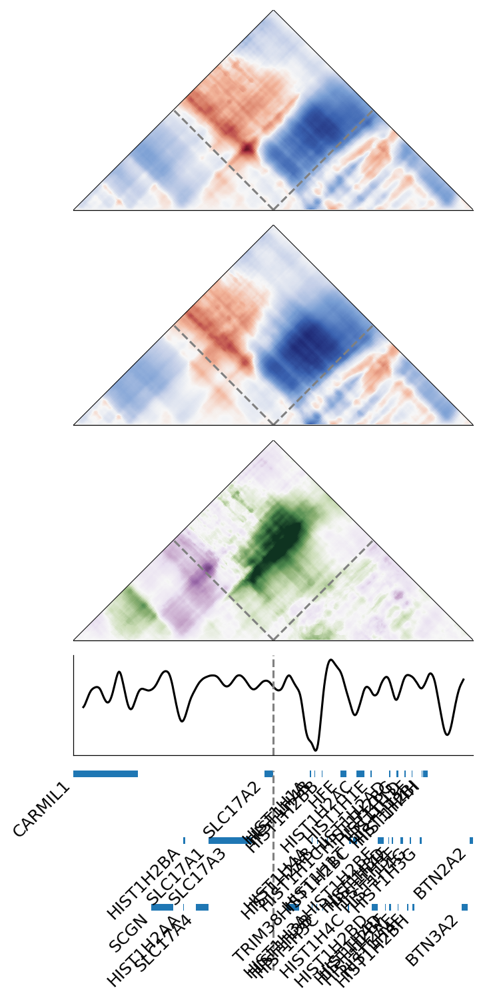

379098
{'spearmanr': 0.8661395367763498, 'pearsonr': 0.9422852375478203, 'mse': 0.018440557704090206}


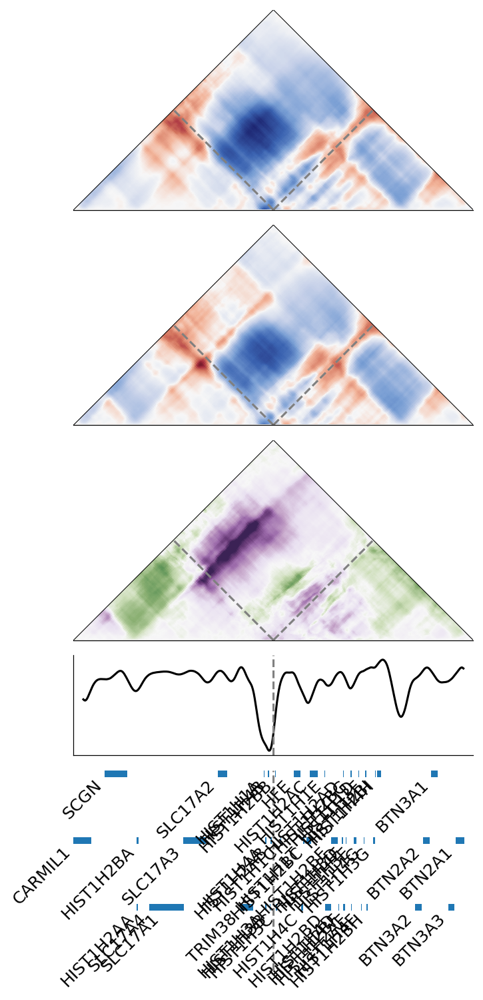

379088
{'spearmanr': 0.9254873503314972, 'pearsonr': 0.9429339399360606, 'mse': 0.02205086589271199}


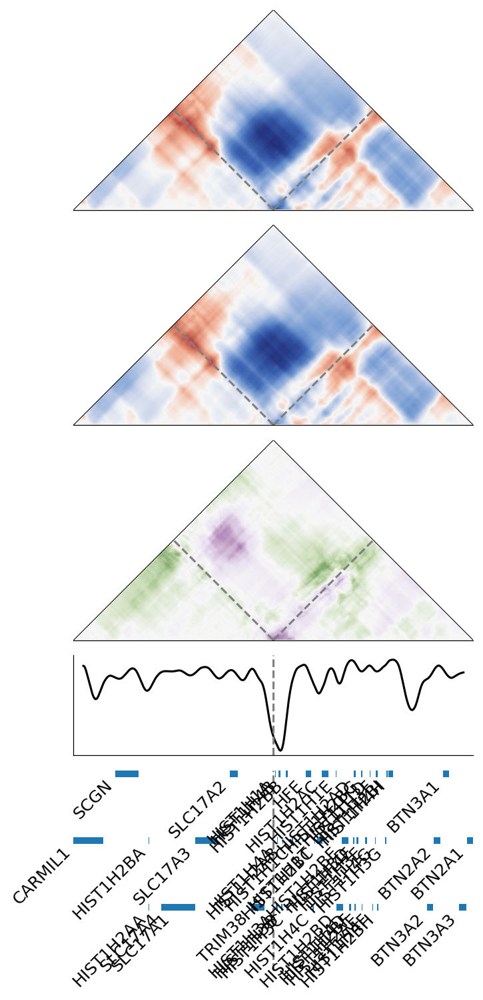

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 25 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'R', 'S', 'T', 'eight', 'four', 'nonmarkingreturn', 'one', 'seven', 'space', 'three', 'two']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 20, 21, 22, 23, 26, 27, 36, 37, 38, 39, 40, 41, 42, 43, 44, 47, 48, 49, 53, 54, 55]
INFO:fontTools.subset:Closed glyph list over 'MATH': 25 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'R', 'S', 'T', 'eight', 'four'

In [27]:
with plt.rc_context(PLOT_RC), \
    pdf_backend.PdfPages(f'{PROJECT_DIR}/figs/paper_figs/fig3_test3.pdf') as pdf:
    #orig_idx_list=alu_high['orig_idx'].sample(4, random_state=729).tolist()
    #orig_idx_list=alu_bdp1['orig_idx'].tolist()
    orig_idx_list=alu_fig3[17:20]['orig_idx'].tolist()
    
    for idx in orig_idx_list:
        try:
                
            print(idx)
            row=alu[alu['orig_idx']==idx]
            
            CHROM=row['CHROM'].values[0]
            POS=row['POS'].values[0]
            END=row['END'].values[0]
            SVLEN=END-POS
            
            seqs=get_seq_utils.get_sequences_SV(CHROM, POS, '-', '-', END, 'DEL', shift=0, revcomp=False)
        
            REF_seq=get_Akita_scores_utils.vector_from_seq(seqs[0])
            REF_pred=get_Akita_scores_utils.map_from_vector(REF_seq)
            
            
            ALT_seq=get_Akita_scores_utils.vector_from_seq(seqs[1])
            ALT_pred=get_Akita_scores_utils.map_from_vector(ALT_seq)
    
    
            #get track
            insulation_REF=scoring.insulation_track(REF_pred)
            insulation_ALT=scoring.insulation_track(ALT_pred)
            insulation_DIFF=insulation_REF-insulation_ALT
    
    
            output, tracks= scoring.vectorMethodToScalar(scoring.insulation_track, REF_pred, ALT_pred, 
                                                         finalCompMetric='all', return_tracks=True)
            print(output)
    
            #decay_DIFF=decay_REF-decay_ALT
    
            #print(decay_REF.shape)
    
            
            var_rel_pos=seqs[2]
            rel_pos_map = get_Akita_scores_utils.get_bin(var_rel_pos[0])
            map_start_coord = POS - var_rel_pos[0] + 32*bin_size
        
            #get genes and lines 
            genes_in_map = plotting_utils.get_genes_in_map(CHROM, map_start_coord, rel_pos_map=rel_pos_map, SVTYPE='DEL', SVLEN=SVLEN)
            lines = plotting_utils.get_var_bins(rel_pos_map, SVTYPE='DEL', SVLEN=SVLEN)        
    
            if len(genes_in_map)>0:
                fig_idx=plotting_utils.plot_maps_genes_tracks([REF_pred, ALT_pred], genes_in_map, lines,  tracks[0],
                                                      cmap_pred=cmap_pred, cmap_diff=cmap_diff)

                #plotting_utils.plot_maps([REF_pred, ALT_pred], lines, scale = 1)
    
            else:
                fig_idx=plotting_utils.plot_maps([REF_pred, ALT_pred], lines, scale = 1)
            
            pdf.savefig(fig_idx, bbox_inches='tight')
            plt.close(fig_idx)
    
        except:
            print(f'error in idx {idx}')


In [ ]:
# figures saved inline above


In [ ]:
#check experimental maps for these same regions 

In [120]:
alu_low[0:10]

,CHROM,POS,END,repName,strand,orig_idx,mse_mean,corr_mean,single_gene_name,single_gene_type,single_gene_overlap_bp,swScore,milliDel,id,#bin,milliIns,milliDiv,SVLEN,REF_start,REF_stop,GC_alu,GC_1kb,GC_10kb,GC_100kb,GC_1Mb,mapp36_alu,mapp36_1kb,mapp36_10kb,mapp36_100kb,mapp36_1Mb,mapp100_alu,mapp100_1kb,mapp100_10kb,mapp100_100kb,mapp100_1Mb,phyloP30_alu,phyloP30_1kb,phyloP30_10kb,phyloP30_100kb,phyloP30_1Mb,phyloP100_alu,phyloP100_1kb,phyloP100_10kb,phyloP100_100kb,phyloP100_1Mb,phastCon30_alu,phastCon30_1kb,phastCon30_10kb,phastCon30_100kb,phastCon30_1Mb,phastCon100_alu,phastCon100_1kb,phastCon100_10kb,phastCon100_100kb,phastCon100_1Mb,alu_count_alu,alu_count_1kb,alu_count_10kb,alu_count_100kb,alu_count_1Mb,promoter_count_alu,promoter_count_1kb,promoter_count_10kb,promoter_count_100kb,promoter_count_1Mb,HFF_CTCF_count_alu,HFF_CTCF_count_1kb,HFF_CTCF_count_10kb,HFF_CTCF_count_100kb,HFF_CTCF_count_1Mb,H1ESC_WGBS_count_alu,H1ESC_WGBS_count_1kb,H1ESC_WGBS_count_10kb,H1ESC_WGBS_count_100kb,H1ESC_WGBS_count_1Mb,gene_PC_overlap_alu,gene_PC_overlap_1kb,gene_PC_overlap_10kb,gene_PC_overlap_100kb,gene_PC_overlap_1Mb,pseudogene_overlap_alu,pseudogene_overlap_1kb,pseudogene_overlap_10kb,pseudogene_overlap_100kb,pseudogene_overlap_1Mb,lincRNA_overlap_alu,lincRNA_overlap_1kb,lincRNA_overlap_10kb,lincRNA_overlap_100kb,lincRNA_overlap_1Mb,ZNF_overlap_alu,ZNF_overlap_1kb,ZNF_overlap_10kb,ZNF_overlap_100kb,ZNF_overlap_1Mb,HFF_H3K9me3_overlap_alu,HFF_H3K9me3_overlap_1kb,HFF_H3K9me3_overlap_10kb,HFF_H3K9me3_overlap_100kb,HFF_H3K9me3_overlap_1Mb,HFF_H3K27me3_overlap_alu,HFF_H3K27me3_overlap_1kb,HFF_H3K27me3_overlap_10kb,HFF_H3K27me3_overlap_100kb,HFF_H3K27me3_overlap_1Mb,repeats_overlap_alu,repeats_overlap_1kb,repeats_overlap_10kb,repeats_overlap_100kb,repeats_overlap_1Mb,phyloP100_highfrac_alu,phyloP100_lowfrac_alu,phyloP100_highfrac_1kb,phyloP100_lowfrac_1kb,phyloP100_highfrac_10kb,phyloP100_lowfrac_10kb,phyloP100_highfrac_100kb,phyloP100_lowfrac_100kb,phyloP100_highfrac_1Mb,phyloP100_lowfrac_1Mb,seg_dup_overlap_alu,seg_dup_overlap_1kb,seg_dup_overlap_10kb,seg_dup_overlap_100kb,seg_dup_overlap_1Mb,self_chain_overlap_alu,self_chain_overlap_1kb,self_chain_overlap_10kb,self_chain_overlap_100kb,self_chain_overlap_1Mb
1166989,chrY,6309424,6309440,AluSz,-,646130,0.000233,0.982798,AC006335.2,unprocessed_pseudogene,16,1824,0,4,633,7,176,16,5785144.0,6833720.0,0.125000,0.358,0.4616,0.40173,0.379432,NaN,NaN,0.431061,0.510625,0.646622,0.535000,0.407186,0.485566,0.596702,0.800831,0.058600,-0.282083,-0.261965,-0.170988,-0.014669,0.055600,-0.210454,-0.154809,0.002031,0.023757,0.009100,0.012166,0.011924,0.035677,0.151697,0.009100,0.016119,0.068842,0.130760,0.130591,1,2,4,32,162,0,0,0,0,1,0,0,0,0,0,0,0,0,12,1531,0.0,0.0,0.0,0.00000,0.002666,1.0,0.655,0.4187,0.27622,0.038544,0.0,0.0,0.0000,0.02213,0.050398,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0000,0.00000,0.023651,0.0,0.0,0.0000,0.00000,0.000428,1.0,0.347,0.0935,0.45506,0.643314,0.0000,0.00000,0.000,0.056,0.0038,0.0549,0.01341,0.02475,0.005520,0.015741,1.0,1.0,1.0000,1.00000,0.915028,1.0,1.0,1.0000,1.00000,1.000000
281627,chr13,58534231,58534247,AluSx1,+,832041,0.000258,0.989500,NaN,NaN,0,1205,6,1,1031,6,144,16,58009951.0,59058527.0,0.062500,0.403,0.3698,0.35711,0.353333,0.973958,0.788659,0.847620,0.928681,0.960069,1.000000,0.995949,0.968575,0.981712,0.993645,-0.265625,-0.028942,0.073288,0.123957,0.132335,0.032562,-0.030727,0.228726,0.102245,0.100490,0.001250,0.040769,0.140550,0.129287,0.130084,0.054437,0.027960,0.231757,0.116260,0.099545,1,3,3,21,192,0,0,0,0,0,0,0,0,0,3,0,8,62,640,7173,0.0,0.0,0.0,0.00000,0.000000,0.0,0.000,0.1787,0.02411,0.003939,0.0,0.0,0.0000,0.00000,0.062061,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.2246,0.23031,0.253880,0.0,0.0,0.0000,0.00119,0.001933,1.0,0.522,0.5808,0.55167,0.481476,0.0625,0.00000,0.018,0.028,0.0604,0.0114,0.02884,0.01723,0.033705,0.019169,0.0,0.0,0.3066,0.07807,0.007445,0.0,0.0,0.3071,0.06751,0.030814
787777,chr4,32510923,32510939,AluSq,+,265022,0.000283,0.991953,NaN,NaN,0,2

### repeat for 1KG (T2T)

In [13]:
# Data path
repo_path=f'{SUPREMO_DIR}/'
genome='CHM13'

chrom_lengths_path = f'{repo_path}/data/chrom_lengths_{genome}'
centromere_coords_path = f'{repo_path}/data/centromere_coords_{genome}'

chrom_lengths = pd.read_table(chrom_lengths_path, header = None, names = ['CHROM', 'chrom_max'])
centromere_coords = pd.read_table(centromere_coords_path, sep = '\t')
fasta_open=pysam.FastaFile(f'{repo_path}/data/{genome}.fa')

svlen_limit=1_000_000
seq_len=1048576
bin_size=2048
###
get_seq_utils.fasta_open = fasta_open
get_seq_utils.chrom_lengths = chrom_lengths
get_seq_utils.centromere_coords = centromere_coords

get_seq_utils.svlen_limit = svlen_limit
get_seq_utils.seq_length = seq_len
get_seq_utils.half_patch_size = round(seq_len/2)

get_Akita_scores_utils.chrom_lengths = chrom_lengths
get_Akita_scores_utils.centromere_coords = centromere_coords




In [78]:
os.listdir(f'{PROJECT_DIR}/results/Schloissnig_1KG_Alu/')

['biallelic_INSDEL_len_noTE_samp1000.txt',
 '1KG_T2T_scored_SV_feature_overlap.csv',
 '.ipynb_checkpoints',
 'Schloissnig_1KG_Alu_DEL_biallelic_scores',
 'biallelic_INSDEL_len_noTE_samp1000_log',
 'Schloissnig_1KG_Alu_DEL_biallelic.txt',
 'biallelic_INSDEL_len_noTE_samp1000_filtered_out',
 'Schloissnig_1KG_Alu_DEL_biallelic_log',
 '1KG_T2T_scored_SV_all_windowannot.txt',
 'Schloissnig_1KG_Alu_INS_biallelic_33619.txt',
 '1KG_T2T_scored_SV_all_noNA_noblacklist.txt',
 '1KG_T2T_scored_SV.txt',
 'Schloissnig_1KG_Alu_DEL_biallelic_filtered_out',
 '1KG_T2T_scored_SV_all_noNA_noblacklist_annotated.txt',
 'input',
 'logs',
 '1KG_T2T_scored_SV_GC.csv',
 'output',
 'INSDEL_noTE',
 '1KG_T2T_scored_SV_all.txt',
 '1KG_T2T_scored_SV_feature_avg.csv',
 'biallelic_INSDEL_len_noTE_samp1000_scores',
 '1KG_T2T_scored_SV_feature_count.csv']

In [82]:
#read in all alu T2T
T2T_outdir=f'{PROJECT_DIR}/results/20260108_aluCHM13_all_scores/'


In [83]:
alu_all_CHM13

,CHROM,POS,REF,ALT,END,SVTYPE,SVLEN,strand,repName,repFamily,repStart,repEnd,repLeft,orig_idx,swScore,perc_div,perc_del,perc_ins,var_index,mse_0,corr_0,mse_0_revcomp,corr_0_revcomp,mse_1,corr_1,mse_1_revcomp,corr_1_revcomp,mse_-1,corr_-1,mse_-1_revcomp,corr_-1_revcomp,mse_mean,mse_median,mse_std,corr_mean,corr_median,corr_std,mse_mean_strandplus,mse_median_strandplus,mse_std_strandplus,corr_mean_strandplus,corr_median_strandplus,corr_std_strandplus,mse_mean_strandminus,mse_median_strandminus,mse_std_strandminus,corr_mean_strandminus,corr_median_strandminus,corr_std_strandminus
0,chrX,4806,-,-,5010,DEL,204,-,AluJr,SINE/Alu,(21),291,87,0,1225,15.6,1.9,1.9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chrX,7023,-,-,7044,DEL,21,+,AluSx,SINE/Alu,1,22,(290),1,879,10.5,0.8,7.7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chrX,7045,-,-,7356,DEL,311,-,AluYm1,SINE/Alu,(12),299,2,2,2422,5.1,0.0,4.5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,chrX,7357,-,-,7476,DEL,119,+,AluSx,SINE/Alu,23,133,(179),3,879,10.5,0.8,7.7,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,chrX,7481,-,-,7523,DEL,42,+,AluSg4,SINE/Alu,125,164,(146),4,951,15.3,0.6,7.9,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204916,chrY,62439957,-,-,62440261,DEL,304,+,AluSp,SINE/Alu,1,306,(7),1204916,2384,8.5,0.3,0.0,4916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1204917,chrY,62440734,-,-,62441036,DEL,302,+,AluSz,SINE/Alu,15,293,(19),1204917,1812,10.9,0.0,7.9,4917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1204918,chrY,62441038,-,-,62441345,DEL,307,+,AluSc8,SINE/Alu,1,311,(0),1204918,2284,10.4,1.0,0.0,4918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1204919,chrY,62442033,-,-,62442310,DEL,277,+,AluSz,SINE/Alu,15,292,(20),1204919,2105,11.9,0.0,0.0,4919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
alu_all_CHM13_SVLENfilter=alu_all_CHM13[(alu_all_CHM13['SVLEN']>=275) & (alu_all_CHM13['SVLEN']<=375)]


,CHROM,POS,REF,ALT,END,SVTYPE,SVLEN,strand,repName,repFamily,repStart,repEnd,repLeft,orig_idx,swScore,perc_div,perc_del,perc_ins,var_index,mse_0,corr_0,mse_0_revcomp,corr_0_revcomp,mse_1,corr_1,mse_1_revcomp,corr_1_revcomp,mse_-1,corr_-1,mse_-1_revcomp,corr_-1_revcomp,mse_mean,mse_median,mse_std,corr_mean,corr_median,corr_std,mse_mean_strandplus,mse_median_strandplus,mse_std_strandplus,corr_mean_strandplus,corr_median_strandplus,corr_std_strandplus,mse_mean_strandminus,mse_median_strandminus,mse_std_strandminus,corr_mean_strandminus,corr_median_strandminus,corr_std_strandminus
2,chrX,7045,-,-,7356,DEL,311,-,AluYm1,SINE/Alu,(12),299,2,2,2422,5.1,0.0,4.5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,chrX,13893,-,-,14196,DEL,303,+,AluYk2,SINE/Alu,1,304,(7),7,2490,7.2,0.0,0.0,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,chrX,14830,-,-,15108,DEL,278,+,AluSg,SINE/Alu,1,280,(30),8,2130,9.7,0.4,0.0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,chrX,16035,-,-,16337,DEL,302,+,AluYm1,SINE/Alu,1,303,(8),12,2536,5.9,0.0,0.0,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,chrX,16930,-,-,17219,DEL,289,+,AluSc8,SINE/Alu,1,291,(20),13,2213,10.3,0.3,0.0,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204916,chrY,62439957,-,-,62440261,DEL,304,+,AluSp,SINE/Alu,1,306,(7),1204916,2384,8.5,0.3,0.0,4916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1204917,chrY,62440734,-,-,62441036,DEL,302,+,AluSz,SINE/Alu,15,293,(19),1204917,1812,10.9,0.0,7.9,4917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1204918,chrY,62441038,-,-,62441345,DEL,307,+,AluSc8,SINE/Alu,1,311,(0),1204918,2284,10.4,1.0,0.0,4918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1204919,chrY,62442033,-,-,62442310,DEL,277,+,AluSz,SINE/Alu,15,292,(20),1204919,2105,11.9,0.0,0.0,4919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
np.nanmean(alu_all_CHM13_SVLENfilter['mse_mean'])

0.01226401044605209

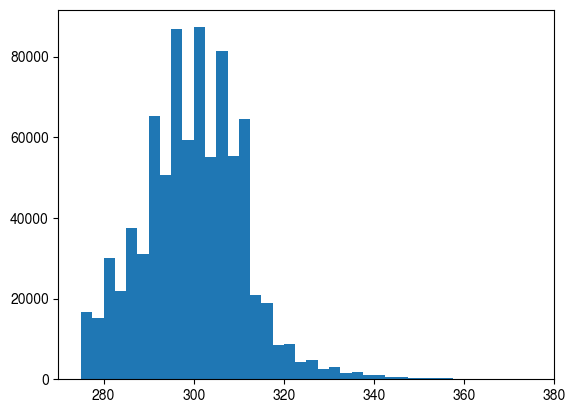

In [86]:
plt.hist(alu_all_CHM13_SVLENfilter['SVLEN'], bins=40)


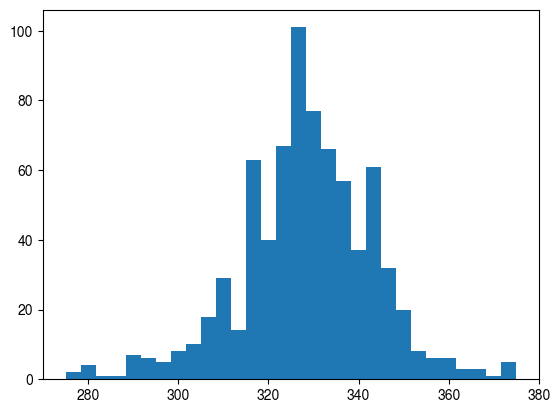

In [89]:
test1=T2T_all[T2T_all['which_SV'].str.contains('Alu')]

plt.hist(test1['SVLEN'], bins=30)


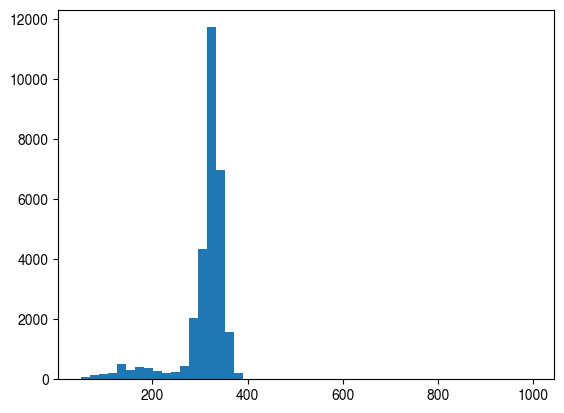

In [94]:
plt.hist(T2T_all_1kgfilter['SVLEN'], bins=50)


In [95]:
np.nanmedian(T2T_all_1kgfilter['SVLEN'])

325.0

In [96]:
np.nanstd(T2T_all_1kgfilter['SVLEN'])

62.847514412696626

In [92]:
T2T_all_nofilter=pd.read_csv(f'{PROJECT_DIR}/results/Schloissnig_1KG_Alu/1KG_T2T_scored_SV_all_noNA_noblacklist_annotated.txt', 
                    sep='\t', index_col=0)
T2T_all_1kgfilter=T2T_all_nofilter[T2T_all_nofilter['SVLEN']<1000]
#filter for len
T2T_all=T2T_all_nofilter[(T2T_all_nofilter['SVLEN']>=275) & (T2T_all_nofilter['SVLEN']<=375)]


/tmp/ipykernel_3332102/2654379757.py:1: DtypeWarning: Columns (59,62,63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  T2T_all_nofilter=pd.read_csv('/pollard/home/szhang20/alu/results/Schloissnig_1KG_Alu/1KG_T2T_scored_SV_all_noNA_noblacklist_annotated.txt',
/tmp/ipykernel_3332102/2654379757.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  T2T_all['MAF'] = T2T_all['AF'].where(T2T_all['AF'] < 0.5, 1 - T2T_all['AF'])


In [77]:
np.mean(T2T_all['mse_mean'])

0.026105653403617528

In [73]:
q99_mse_T2T=np.nanquantile(T2T_all['mse_mean'], 0.95)
q99_corr_T2T=np.nanquantile(T2T_all['corr_mean'], 0.50)

T2T_all=T2T_all[(T2T_all['corr_mean']<q99_corr_T2T) & (T2T_all['mse_mean']>q99_mse_T2T)].sort_values('mse_mean', ascending=False)


,CHROM,POS,REF,ALT,ID,orig_idx,FAM_N,ITYPE_N,SV_TYPE,NOT_CANONICAL,CONFORMATION,TSD_SEQ,POLYA_SEQ,TSD_LEN,POLYA_LEN,IS_3PRIME_TRUNCATED,INFO,is_high_Fst,SVLEN,var_index,mse_0,corr_0,mse_0_revcomp,corr_0_revcomp,mse_1,corr_1,mse_1_revcomp,corr_1_revcomp,mse_-1,corr_-1,mse_-1_revcomp,corr_-1_revcomp,mse_mean,mse_median,mse_std,corr_mean,corr_median,corr_std,AF,AF_AFR,AF_AMR,AF_EAS,AF_FIN,AF_NFE,AF_SAS,AC,AC_AFR,AC_AMR,AC_EAS,AC_FIN,AC_NFE,AC_SAS,which_SV,END,SVTYPE,REF_start,REF_stop,var_rel_pos_REF,CHROM_T2T,POS_T2T,END_T2T,repName_T2T,mse_mean_T2T,corr_mean_T2T,n_overlap_T2T,REPEAT_BKP,Alu_INS_type,alu_insert_subfamily,REPEAT_INS_TYPE,MAF
3900,chr16,2238267,ATTTTTAGTAGAGACGGGGTTTCTCCGTGTTAGCCAGGATGGTCTC...,A,chr16-2238267-DEL->s678200>s678202-311,4952,NaN,NaN,DEL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC=4;AC_AFR=3;AC_AMR=1;AC_EAS=0;AC_FIN=0;AC_NF...,NaN,312,4952,0.053313,0.884892,0.131176,0.800594,0.039960,0.924074,0.047535,0.913837,0.067998,0.878546,0.053876,0.887558,0.065643,0.053595,0.033401,0.881584,0.886225,0.043499,0.002068,0.005859,0.003086,0.0,0.00,0.000000,0.000000,4,3,1,0,0,0,0,300bp_DEL,2238578,DEL,1714135,2762711,524131,chr16,2238391.0,2238701.0,AluY,0.0535379977197639,0.8971189247913439,187.0,NaN,NaN,NaN,NaN,0.002068
4627,chr2,209814369,TTATTTATGCCAATAAGAGTGACAGTACCCTGTAAAGAAGCTACTA...,T,chr2-209814369-DEL->s104031>s104033-351,5700,NaN,NaN,DEL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC=1;AC_AFR=0;AC_AMR=0;AC_EAS=0;AC_FIN=0;AC_NF...,NaN,352,5700,0.079126,0.652250,0.050349,0.815009,0.058486,0.783273,0.066272,0.757540,0.063614,0.684383,0.066103,0.742376,0.063991,0.064858,0.009542,0.739138,0.749958,0.060994,0.000517,0.000000,0.000000,0.0,0.00,0.000000,0.002632,1,0,0,0,0,0,1,300bp_DEL,209814720,DEL,209290257,210338833,524111,.,-1.0,-1.0,.,-1,.,0.0,NaN,NaN,NaN,NaN,0.000517
26733,chr19,52939348,G,GCAACATGGCGAAACCCTGTCTCTACAAACAATACAAAAATTAGCT...,chr19-52939348-INS->s778203>s1024282>s1024283>...,1749,NaN,DUP,INS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC=1;AC_AFR=0;AC_AMR=0;AC_EAS=0;AC_FIN=0;AC_NF...,NaN,312,1749,0.014676,0.981947,0.042413,0.948372,0.016885,0.979350,0.102586,0.868990,0.019448,0.977388,0.135061,0.842607,0.055178,0.030931,0.051333,0.933109,0.962880,0.061675,0.000517,0.000000,0.000000,0.0,0.00,0.000000,0.002632,1,0,0,0,0,0,1,300bp_INS,52939349,INS,52415060,53463636,524287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000517
7655,chr17,705519,A,ATTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...,chr17-705519-INS->s704300>s1031025>s704301-342,11893,Alu,solo,INS,NaN,FOR+POLYA,GGCCGACAATACTTAATTTTTTTT,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,24.0,42,0.0,AC=1;AC_AFR=1;AC_AMR=0;AC_EAS=0;AC_FIN=0;AC_NF...,0.0,343,1655,0.090603,0.914221,0.074812,0.906610,0.043338,0.942194,0.049110,0.949856,0.024579,0.965506,0.042586,0.930219,0.054171,0.046224,0.024109,0.934768,0.936206,0.022196,0.000517,0.001953,0.000000,0.0,0.00,0.000000,0.000000,1,1,0,0,0,0,0,Alu_INS,705520,INS,181231,1229807,524287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AluJb,NaN,0.000517
4426,chr19,53327855,GGAGGCTGAGTTAGGAGAATCGCTTGAGCCGGGGAATTTGAGACCA...,G,chr19-53327855-DEL->s778380>s778382-358,5498,NaN,NaN,DEL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC=1;AC_AFR=1;AC_AMR=0;AC_EAS=0;AC_FIN=0;AC_NF...,NaN,359,5498,0.130471,0.747083,0.074062,0.838672,0.026870,0.941487,0.029917,0.933657,0.016299,0.965960,0.025870,0.939561,0.050581,0.028393,0.044066,0.894403,0.936609,0.084530,0.000517,0.001953,0.000000,0.0,0.00,0.000000,0.000000,1,1,0,0,0,0,0,300bp_DEL,53328213,DEL,52803746,53852322,524108,chr19,53327819.0,53328138.0,AluJr,0.0439188260046088,0.9079335284048268,283.0,NaN,NaN,NaN,NaN,0.000517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1410,chr1,201836008,T,TTAAAAATAAATGGGCCGGGCGCGGTGGCTCACGCCTGTAATCCCA...,chr1-201836008-INS->s13119>s1023102>s13120-330,5648,Alu,solo,INS,NaN,FOR+

In [75]:
T2T_all.iloc[3610]

IndexError: single positional indexer is out-of-bounds

In [57]:
# T2T_all_DEL=T2T_all[T2T_all['mse_mean_T2T']!='.']
# T2T_all_DEL=T2T_all_DEL[T2T_all_DEL['mse_mean_T2T'].astype(float)>0]



4952
300bp_DEL at 0.0020682523267838 MSE: 0.065643, CORR: 0.881584,chr16 : 2238267 - 2238578
{'spearmanr': 0.9179372234633478, 'pearsonr': 0.9460332492858434, 'mse': 0.00953428965769305}


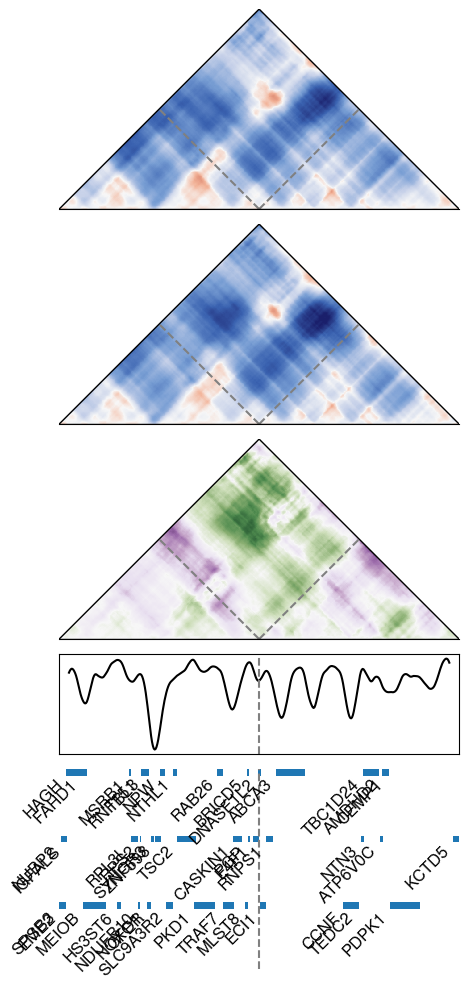

5700
300bp_DEL at 0.0005170630816959 MSE: 0.063991, CORR: 0.739138,chr2 : 209814369 - 209814720
{'spearmanr': 0.6426122230548914, 'pearsonr': 0.737774411955974, 'mse': 0.016241510564241134}


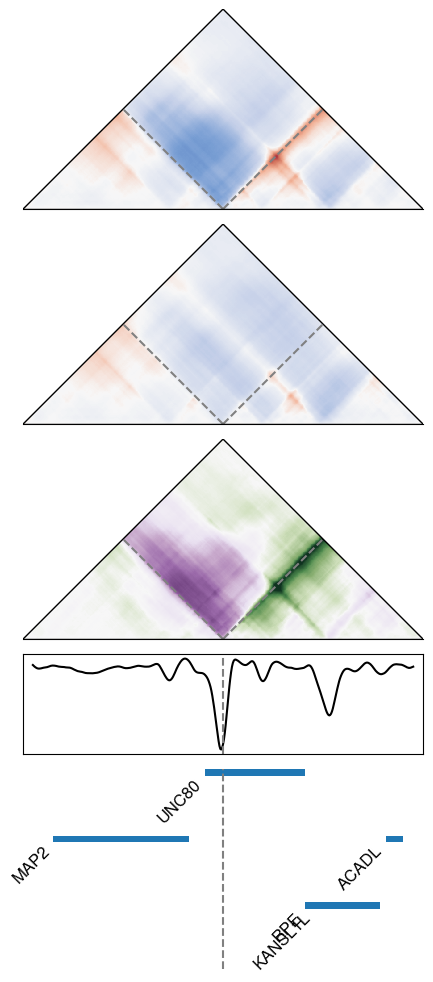

1749
300bp_INS at 0.0005170630816959 MSE: 0.055178, CORR: 0.933109,chr19 : 52939348 - 52939349
{'spearmanr': 0.991331472826541, 'pearsonr': 0.9935670715058232, 'mse': 0.001199804542316746}


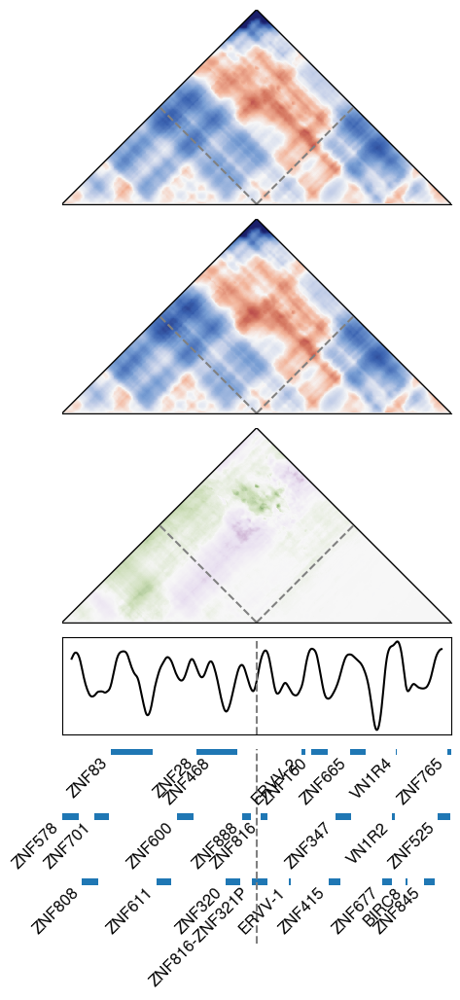

5498
300bp_DEL at 0.0005170630816959 MSE: 0.050581, CORR: 0.894403,chr19 : 53327855 - 53328213
{'spearmanr': 0.9149453176851827, 'pearsonr': 0.9094668109221187, 'mse': 0.017158666726602257}


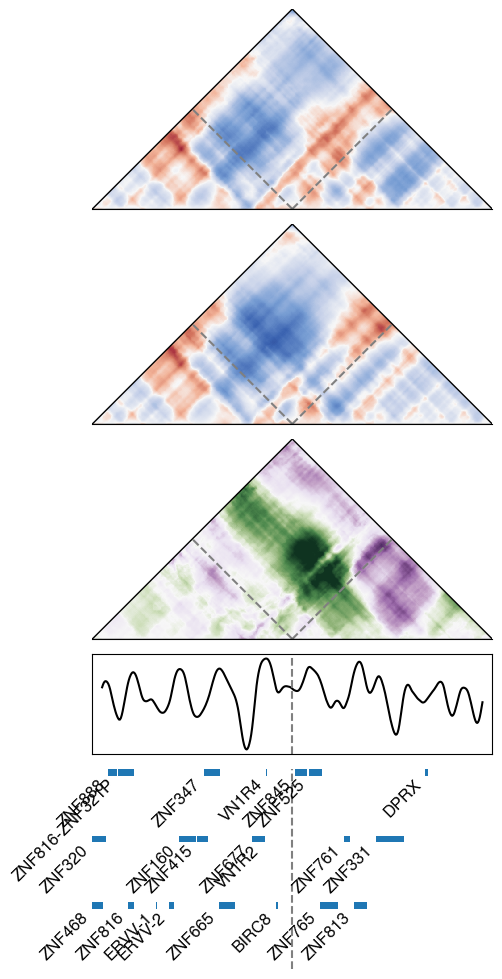

1747
300bp_INS at 0.0072388831437435 MSE: 0.045829, CORR: 0.888635,chr19 : 52215592 - 52215593
{'spearmanr': 0.9850002419912457, 'pearsonr': 0.9871434296957058, 'mse': 0.0022559736757214134}


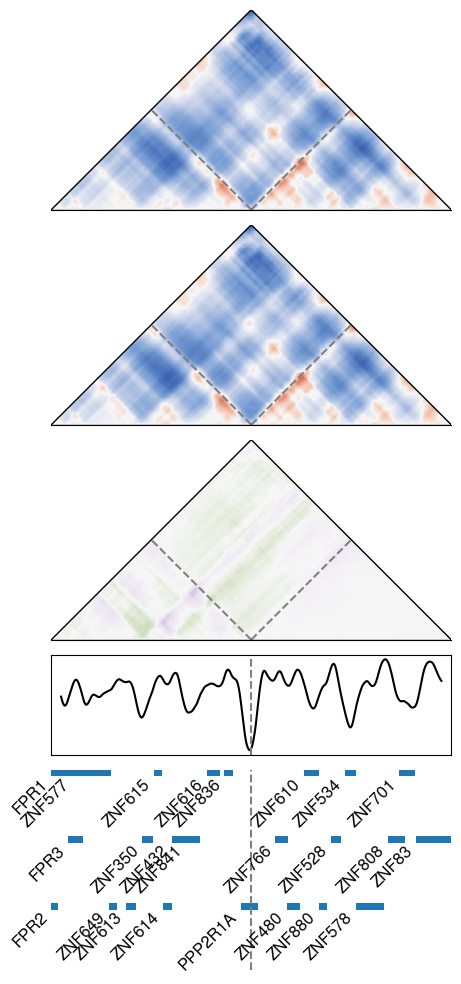

3807
300bp_INS at 0.2414684591520165 MSE: 0.044521, CORR: 0.951253,chr9 : 149002449 - 149002450
{'spearmanr': 0.9563077869700198, 'pearsonr': 0.9449582432812293, 'mse': 0.004226894904822465}


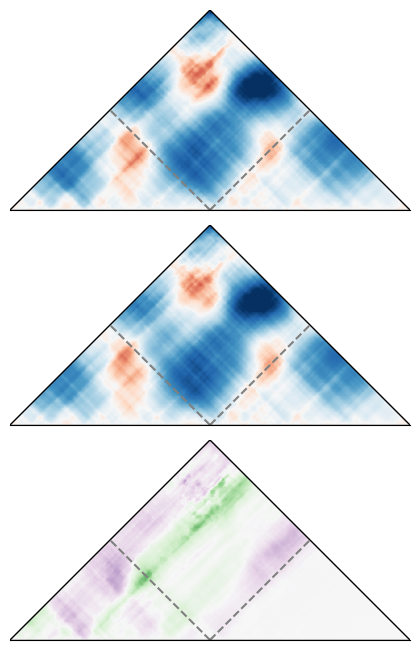

1342
300bp_INS at 0.0077559462254395 MSE: 0.044243, CORR: 0.932415,chr16 : 95672270 - 95672271
{'spearmanr': 0.923890670513043, 'pearsonr': 0.9537508647747936, 'mse': 0.0036384300247546577}


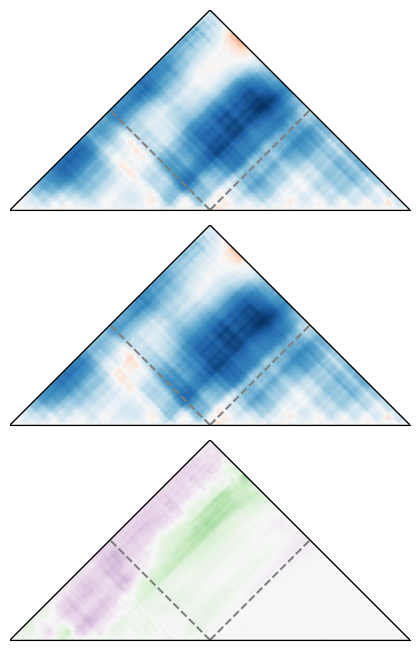

1085
300bp_INS at 0.40847983453981385 MSE: 0.042286, CORR: 0.902277,chr14 : 94189335 - 94189336
{'spearmanr': 0.9689810380592117, 'pearsonr': 0.9685074540045531, 'mse': 0.0046207101135189305}


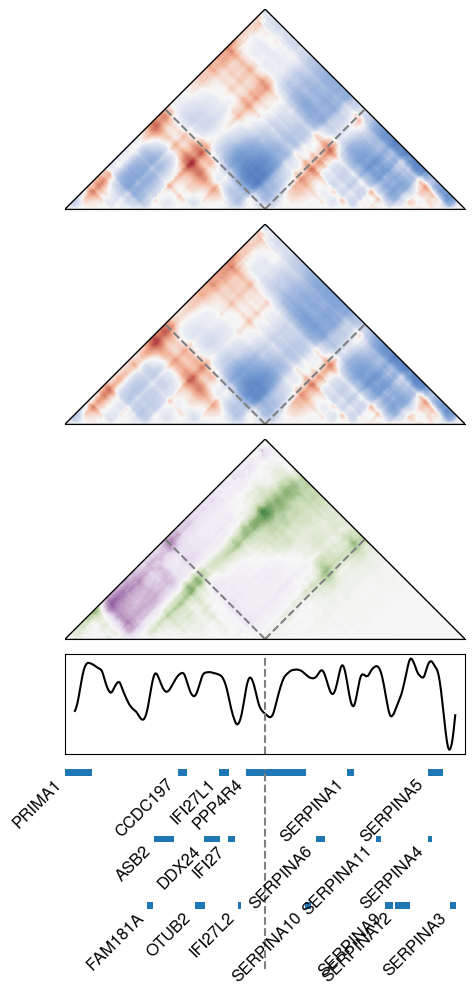

2294
300bp_INS at 0.0180972078593588 MSE: 0.042174, CORR: 0.897825,chr22 : 39394225 - 39394226
{'spearmanr': 0.9825991339487823, 'pearsonr': 0.9914053263077696, 'mse': 0.0012643148945135404}


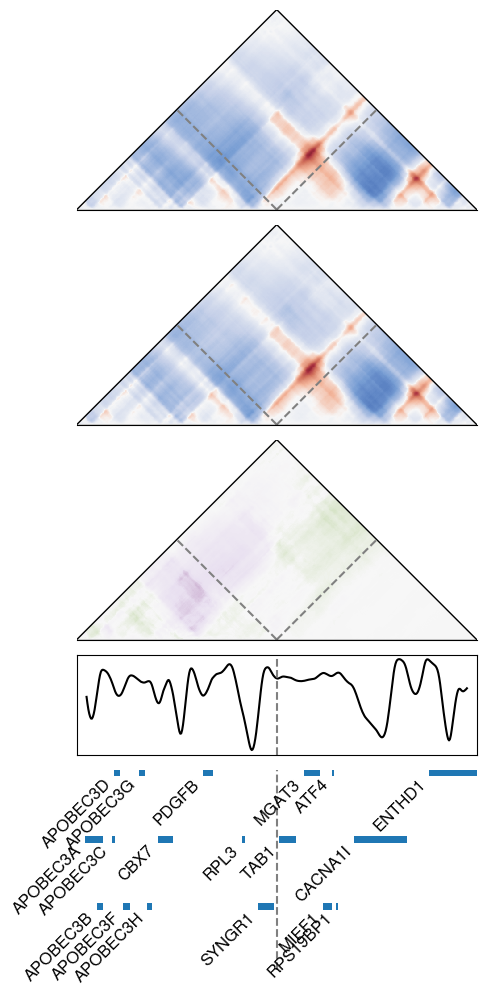

1086
300bp_INS at 0.2006204756980351 MSE: 0.041901, CORR: 0.899006,chr14 : 94189335 - 94189336
{'spearmanr': 0.9689810380592117, 'pearsonr': 0.9685074540045531, 'mse': 0.0046207101135189305}


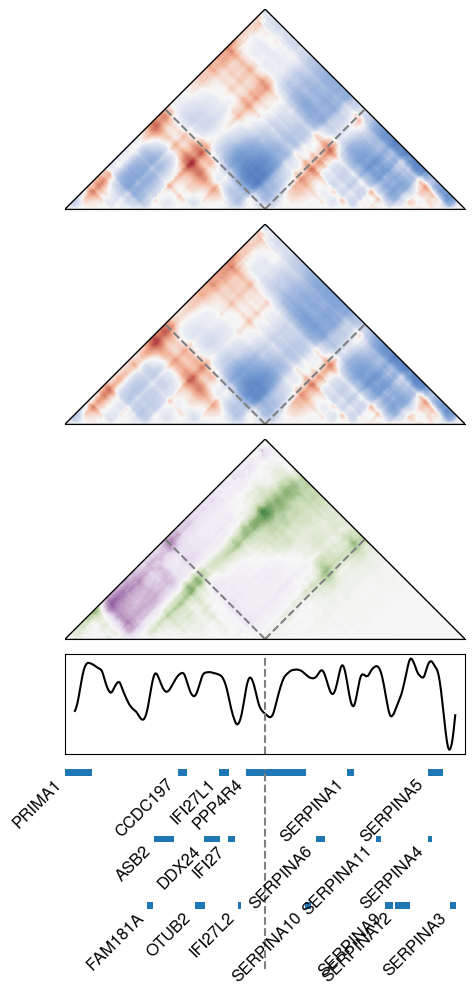

4958
300bp_DEL at 0.1339193381592554 MSE: 0.040257, CORR: 0.917847,chr16 : 3240391 - 3240685
{'spearmanr': 0.9399892537390729, 'pearsonr': 0.9411220126940822, 'mse': 0.006203873105767159}


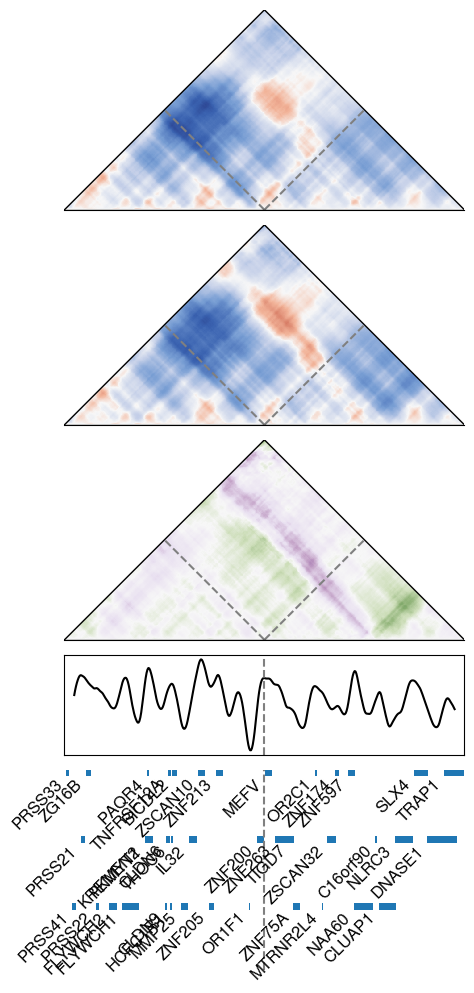

4951
300bp_DEL at 0.0103412616339193 MSE: 0.040215, CORR: 0.922356,chr16 : 2187703 - 2187990
{'spearmanr': 0.8848002986511069, 'pearsonr': 0.9164068804508401, 'mse': 0.0126515698015101}


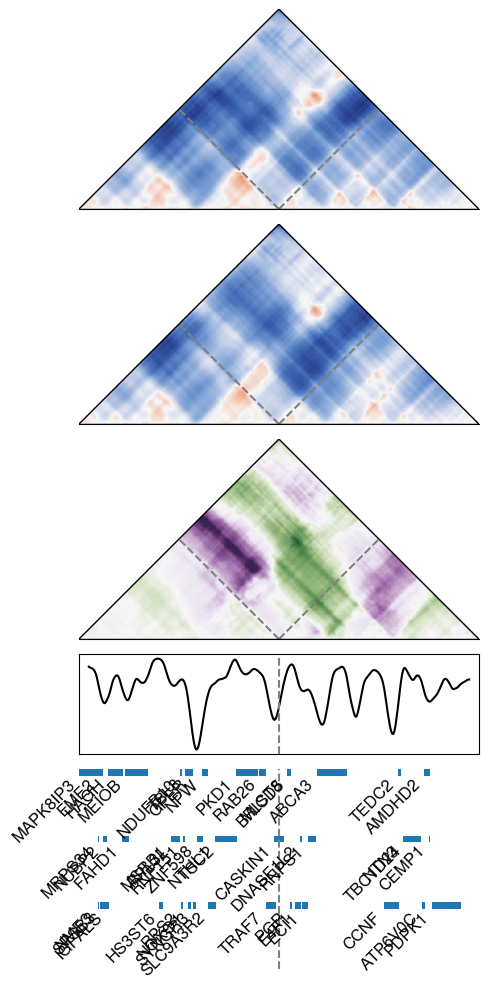

1358
300bp_INS at 0.030506721820062 MSE: 0.040141, CORR: 0.951394,chr17 : 198600 - 198601
{'spearmanr': 0.9427293036601715, 'pearsonr': 0.9590712679818258, 'mse': 0.005716345044919784}


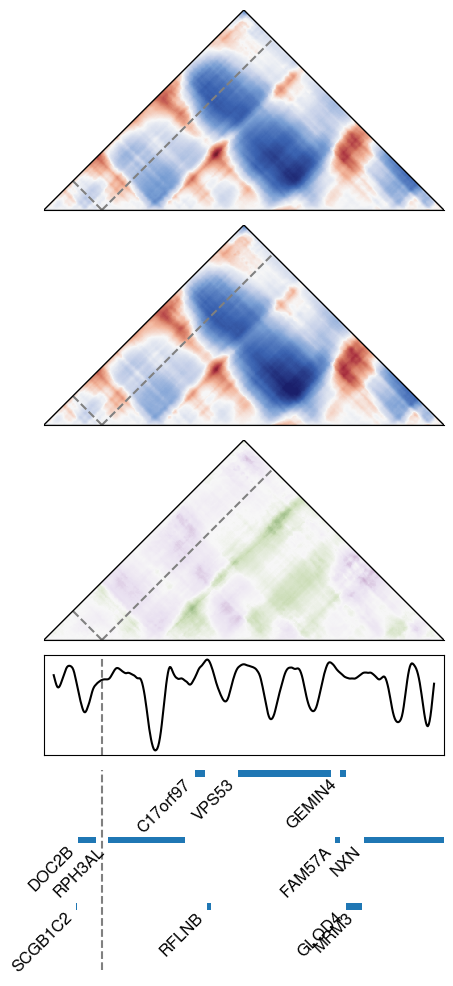

7224
300bp_DEL at 0.1799379524301964 MSE: 0.039906, CORR: 0.926302,chr9 : 35393354 - 35393660
{'spearmanr': 0.9090533703215153, 'pearsonr': 0.9352268379806434, 'mse': 0.005928115477964409}


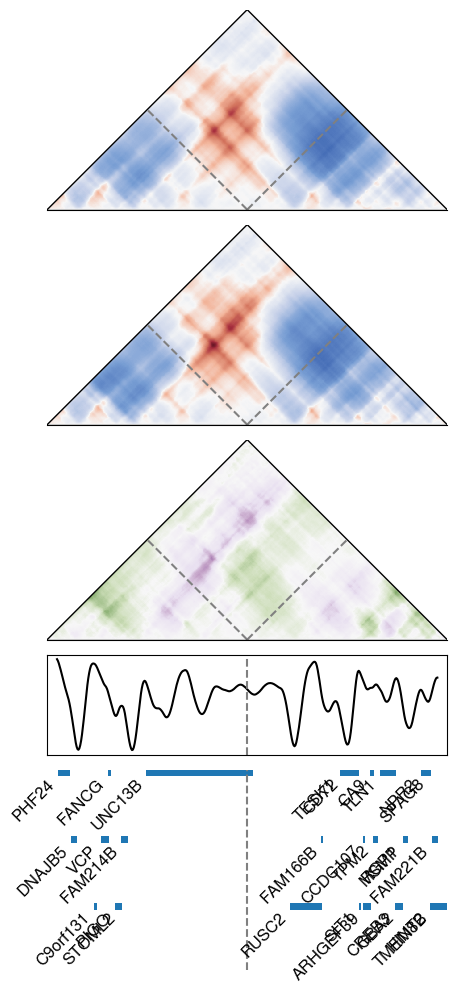

6804
300bp_DEL at 0.0005170630816959 MSE: 0.039807, CORR: 0.936062,chr7 : 6239791 - 6240132
{'spearmanr': 0.9397945818005937, 'pearsonr': 0.9429445669711094, 'mse': 0.005738287293784035}


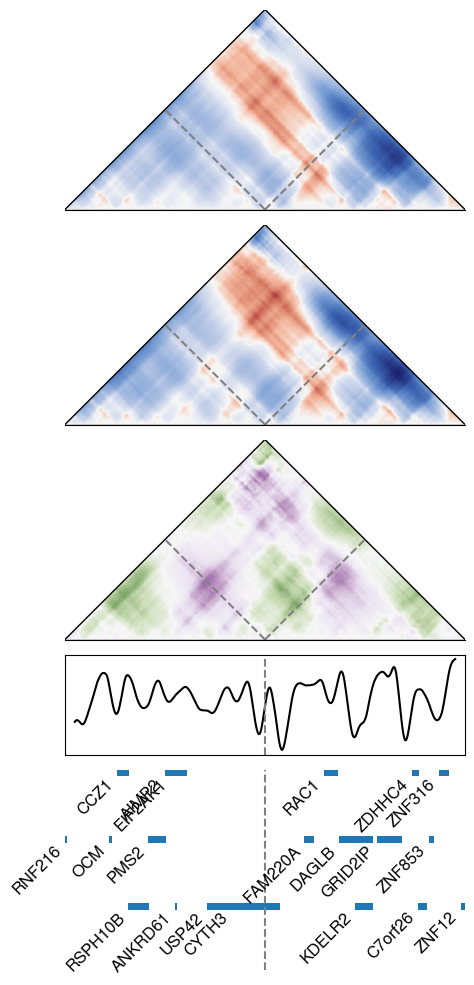

4957
300bp_DEL at 0.0191313340227507 MSE: 0.039154, CORR: 0.907757,chr16 : 2986656 - 2987027
{'spearmanr': 0.9447799097326413, 'pearsonr': 0.9478181334833624, 'mse': 0.006769290975358995}


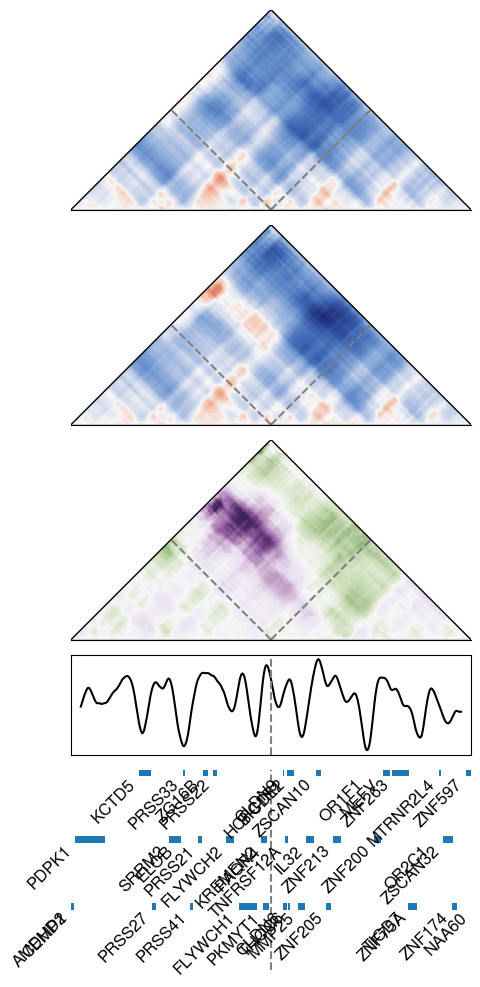

1359
300bp_INS at 0.46225439503619437 MSE: 0.038218, CORR: 0.955520,chr17 : 204936 - 204937
{'spearmanr': 0.9447922404967573, 'pearsonr': 0.9591015240593949, 'mse': 0.005703348853644005}


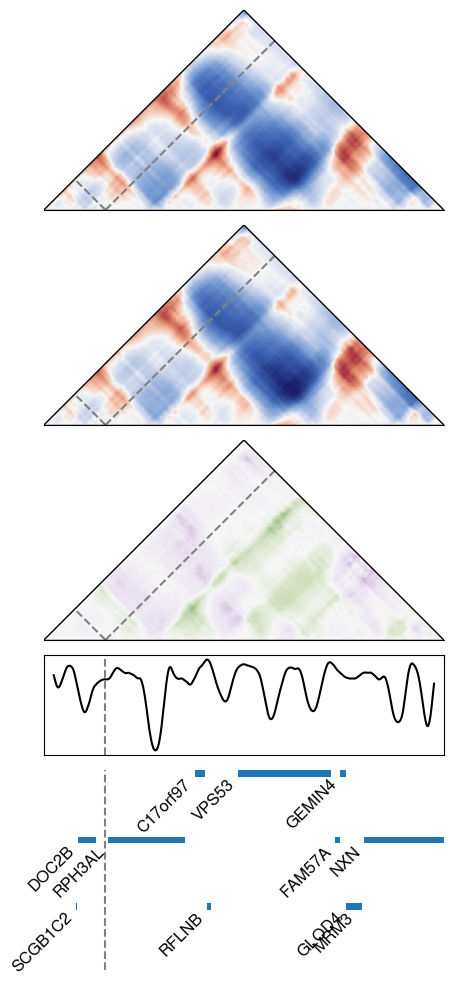

5710
300bp_DEL at 0.0005170630816959 MSE: 0.038179, CORR: 0.934961,chr2 : 219682895 - 219683209
{'spearmanr': 0.9235725367988534, 'pearsonr': 0.9370631748165628, 'mse': 0.011516506945229677}


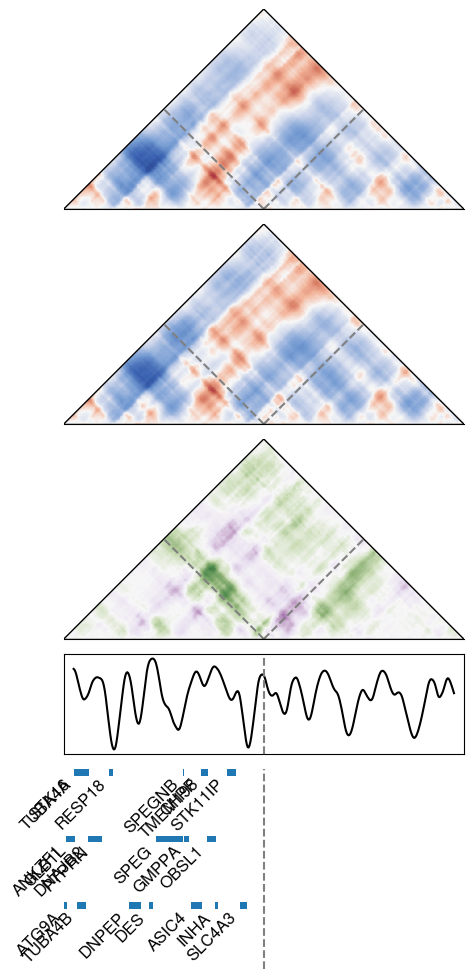

2549
300bp_INS at 0.2952430196483971 MSE: 0.037943, CORR: 0.801273,chr4 : 2807569 - 2807570
{'spearmanr': 0.9571317902820631, 'pearsonr': 0.962160795132406, 'mse': 0.0033935184152028494}


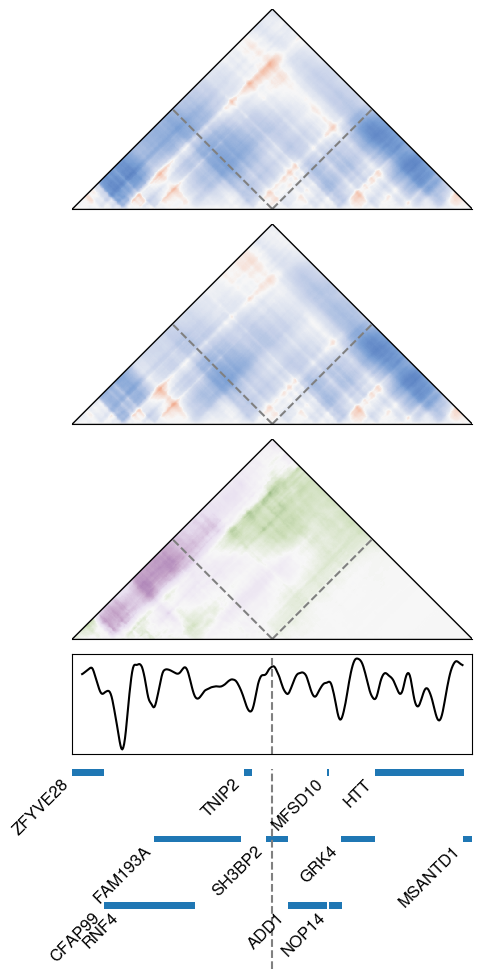

5499
300bp_DEL at 0.0413650465356773 MSE: 0.037821, CORR: 0.929325,chr19 : 53491853 - 53492170
{'spearmanr': 0.9708232542181232, 'pearsonr': 0.9595067005706304, 'mse': 0.00792301825505639}


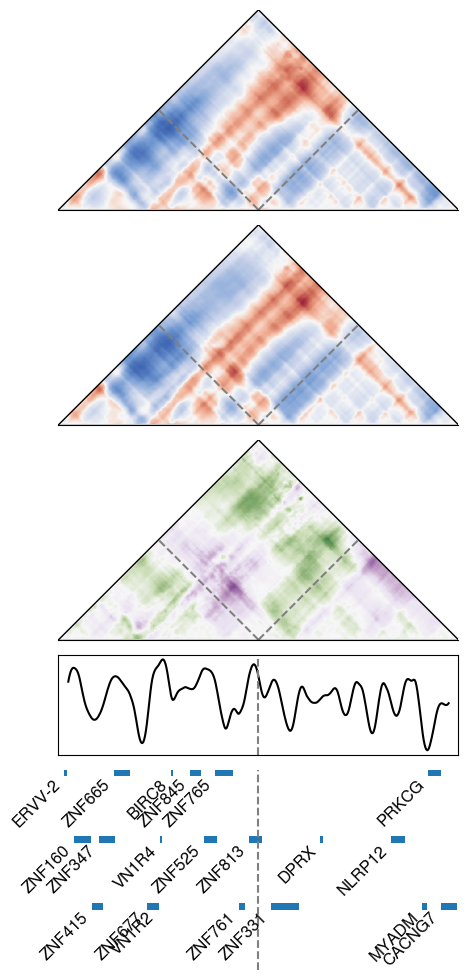

1375
300bp_INS at 0.030506721820062 MSE: 0.037510, CORR: 0.947094,chr17 : 960673 - 960674
{'spearmanr': 0.975122220992571, 'pearsonr': 0.9853702111035705, 'mse': 0.002408198425029045}


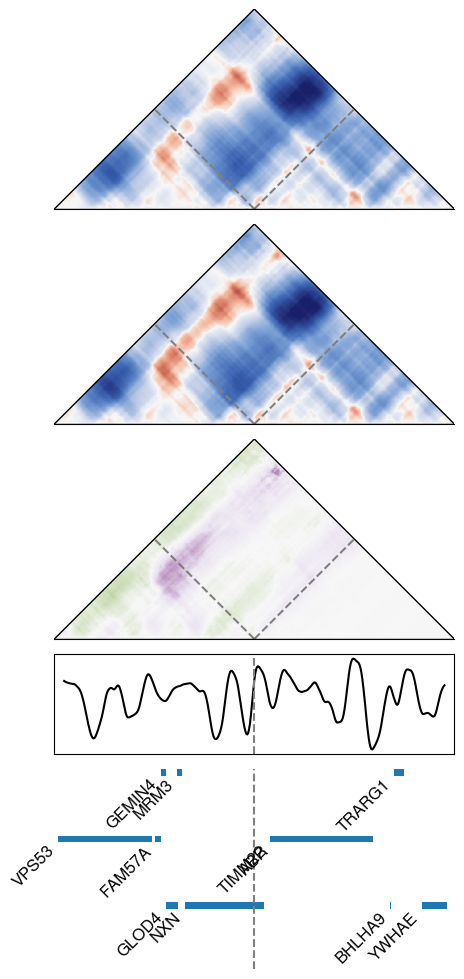

5070
300bp_DEL at 0.0015511892450879 MSE: 0.037238, CORR: 0.939407,chr16 : 95623414 - 95623756
{'spearmanr': 0.8011394550850376, 'pearsonr': 0.8522517570580763, 'mse': 0.014352296630195315}


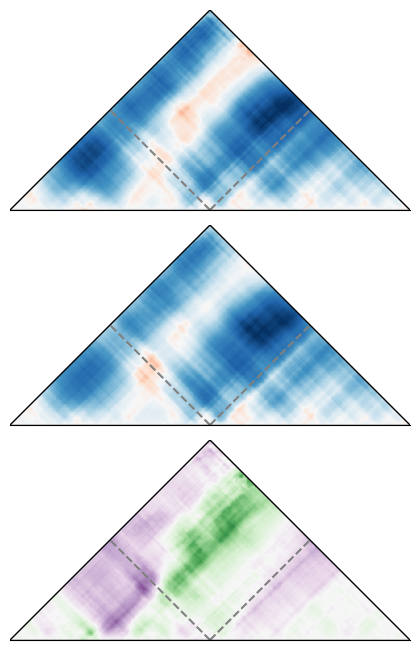

7031
300bp_DEL at 0.0005170630816959 MSE: 0.036987, CORR: 0.927286,chr8 : 17919660 - 17919937
{'spearmanr': 0.9564705530563494, 'pearsonr': 0.9668637263723642, 'mse': 0.004266326734170293}


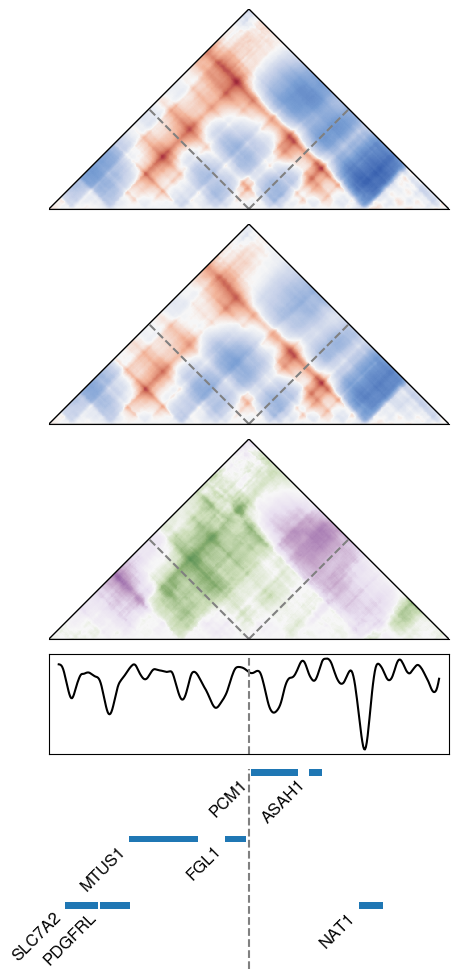

5495
300bp_DEL at 0.0010341261633919 MSE: 0.036608, CORR: 0.912575,chr19 : 52479206 - 52479512
{'spearmanr': 0.9377011263228213, 'pearsonr': 0.966582778553561, 'mse': 0.006524592879818767}


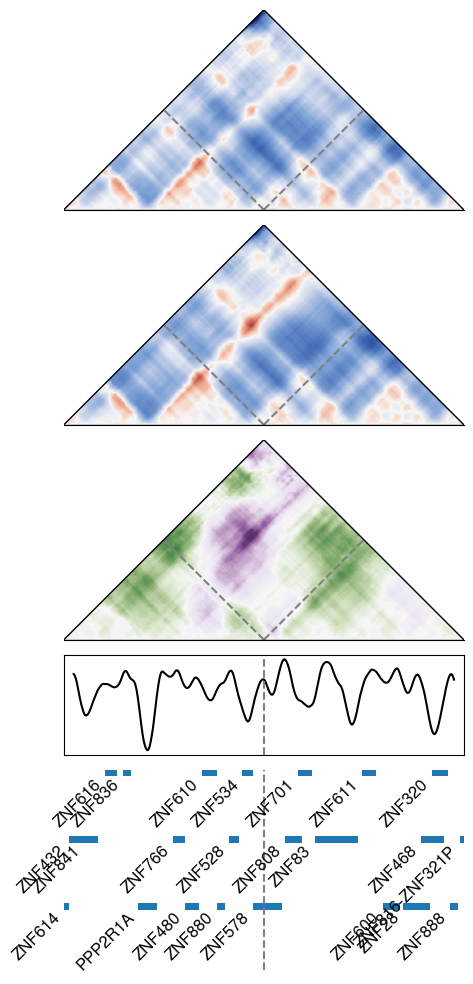

5223
300bp_DEL at 0.0351602895553257 MSE: 0.036567, CORR: 0.914790,chr17 : 76336834 - 76337143
{'spearmanr': 0.9523881453266866, 'pearsonr': 0.955429917110839, 'mse': 0.006424661581551877}


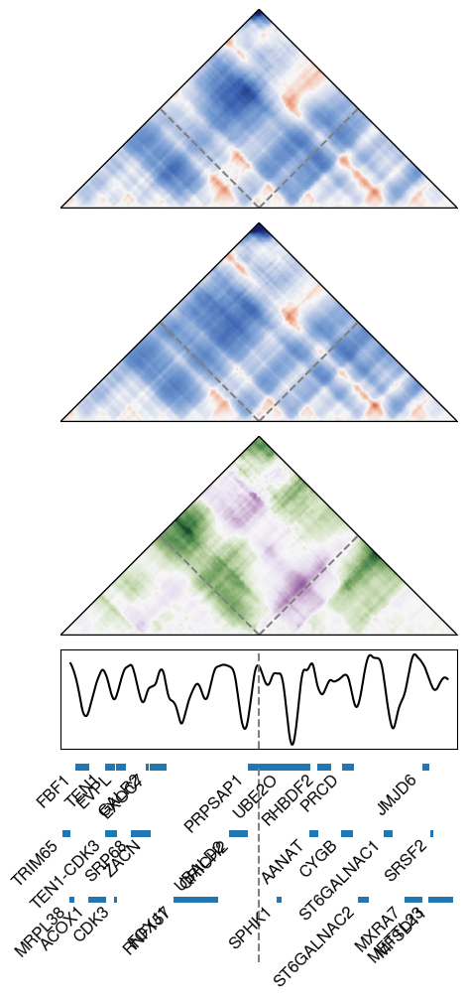

1346
300bp_INS at 0.1292657704239917 MSE: 0.036390, CORR: 0.932827,chr16 : 95703272 - 95703273
{'spearmanr': 0.8988962116501676, 'pearsonr': 0.9227970848877722, 'mse': 0.007337891874716761}


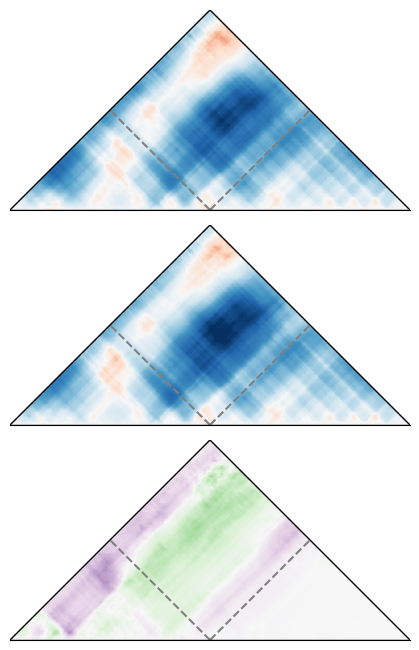

5957
300bp_DEL at 0.0031023784901758 MSE: 0.036163, CORR: 0.907434,chr22 : 39577906 - 39578204
{'spearmanr': 0.9113402646613556, 'pearsonr': 0.9528893215853558, 'mse': 0.00841521752854907}


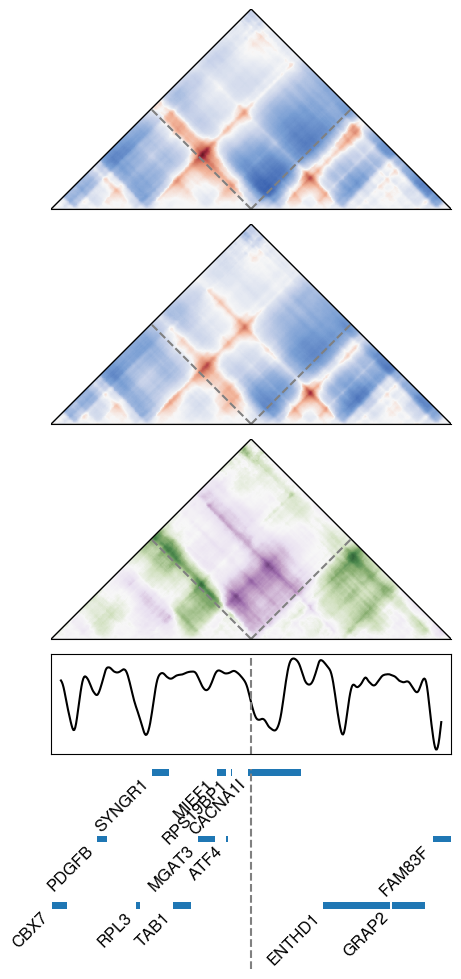

2083
300bp_INS at 0.0005170630816959 MSE: 0.035866, CORR: 0.862538,chr2 : 241906284 - 241906285
{'spearmanr': 0.9827447910999011, 'pearsonr': 0.9812368591046156, 'mse': 0.0012271348555183592}


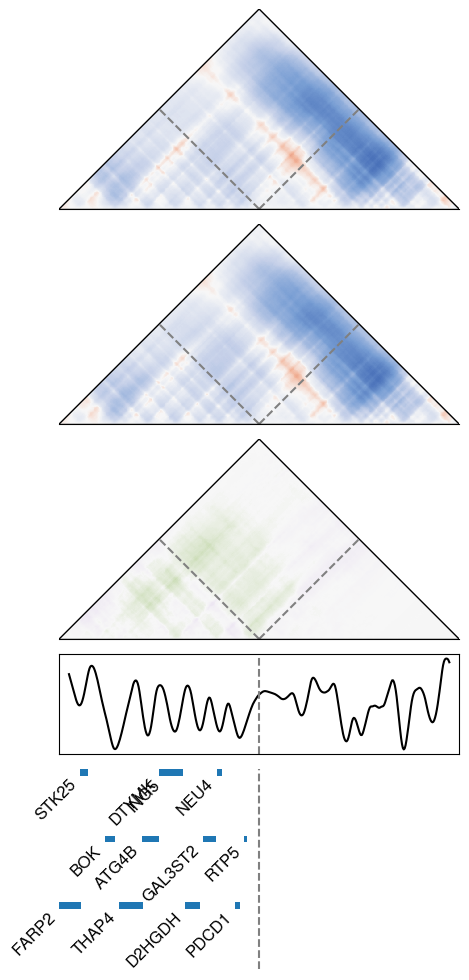

288
300bp_INS at 0.0010341261633919 MSE: 0.035505, CORR: 0.890760,chr10 : 604496 - 604497
{'spearmanr': 0.9618812923503947, 'pearsonr': 0.972308167909014, 'mse': 0.001903396234243116}


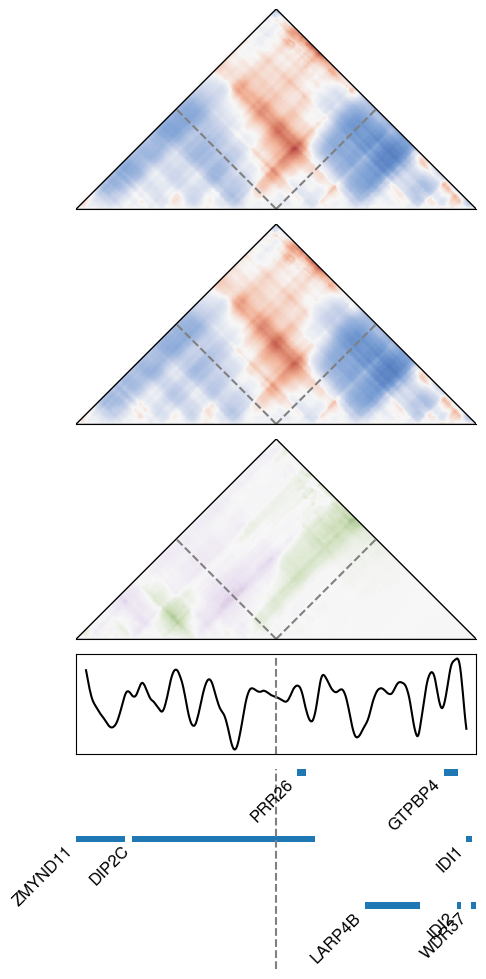

5076
300bp_DEL at 0.0005170630816959 MSE: 0.035231, CORR: 0.932991,chr16 : 95857023 - 95857336
{'spearmanr': 0.9480302991535855, 'pearsonr': 0.9575826931753849, 'mse': 0.00428828455087969}


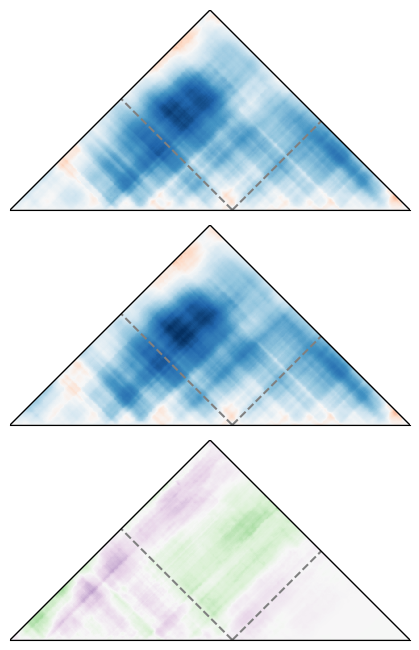

In [76]:
with plt.rc_context(PLOT_RC), \
     pdf_backend.PdfPages(f'{PROJECT_DIR}/figs/paper_figs/test_T2T_nonAlu.pdf') as pdf:
    
    orig_idx_list=T2T_all[~T2T_all['which_SV'].str.contains('Alu')]['orig_idx'].tolist()
    
    for idx in orig_idx_list[0:30]:
        if 1==1:
                
            print(idx)
            row=T2T_all[T2T_all['orig_idx']==idx]
            
            CHROM=row['CHROM'].values[0]
            POS=row['POS'].values[0]
            END=row['END'].values[0]
            SVLEN=END-POS
            print(f'{row['which_SV'].values[0]} at {row['MAF'].values[0]}',
                    f'MSE: {row['mse_mean'].values[0]:3f}, CORR: {row['corr_mean'].values[0]:3f},'
                    f'{CHROM} : {POS} - {END}')
            
            seqs=get_seq_utils.get_sequences_SV(CHROM, POS, '-', '-', END, 'DEL', shift=0, revcomp=False)
        
            REF_seq=get_Akita_scores_utils.vector_from_seq(seqs[0])
            REF_pred=get_Akita_scores_utils.map_from_vector(REF_seq)
            
            
            ALT_seq=get_Akita_scores_utils.vector_from_seq(seqs[1])
            ALT_pred=get_Akita_scores_utils.map_from_vector(ALT_seq)
    
    
            #get track
            insulation_REF=scoring.insulation_track(REF_pred)
            insulation_ALT=scoring.insulation_track(ALT_pred)
            insulation_DIFF=insulation_REF-insulation_ALT
    
    
            output, tracks= scoring.vectorMethodToScalar(scoring.insulation_track, REF_pred, ALT_pred, 
                                                         finalCompMetric='all', return_tracks=True)
            print(output)
    
            #decay_DIFF=decay_REF-decay_ALT
    
            #print(decay_REF.shape)
    
            
            var_rel_pos=seqs[2]
            rel_pos_map = get_Akita_scores_utils.get_bin(var_rel_pos[0])
            map_start_coord = POS - var_rel_pos[0] + 32*bin_size
        
            #get genes and lines 
            genes_in_map = plotting_utils.get_genes_in_map(CHROM, map_start_coord, rel_pos_map=rel_pos_map, SVTYPE='DEL', SVLEN=SVLEN)
            lines = plotting_utils.get_var_bins(rel_pos_map, SVTYPE='DEL', SVLEN=SVLEN)        
    
            if len(genes_in_map)>0:
                fig_idx=plotting_utils.plot_maps_genes_tracks([REF_pred, ALT_pred], genes_in_map, lines,  tracks[0],
                                                      cmap_pred=cmap_pred, cmap_diff=cmap_diff)
                #plotting_utils.plot_maps([REF_pred, ALT_pred], lines, scale = 1)
    
            else:
                fig_idx=plotting_utils.plot_maps([REF_pred, ALT_pred], lines, scale = 1)
    
            pdf.savefig(fig_idx, bbox_inches='tight')
            plt.close(fig_idx)
    
        else:
            print(f'error in idx {idx}')
